# Minimal validation: 3-sector extension
Checks that the model initializes, finds the steady state, and that the
extension-specific quantities (two tradeable sectors, inner flat-CES nest,
sector-specific material costs) are internally consistent.  
Uses `T=100` to keep runtime short.

In [49]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
import os
# GEModelTools and EconModel are local packages — add to path if not already installed
if r'c:\Users\kons-ana\GEModelTools' not in sys.path:
    sys.path.insert(0, r'c:\Users\kons-ana\GEModelTools')
from IHANKModel import IHANKModelClass

model = IHANKModelClass(name='test')
#model.par.T = 200   # reduce horizon for speed
par = model.par
ss  = model.ss

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Steady state

In [50]:
model.find_ss(do_print=True)

household problem in ss solved in 6.3 secs [372 iterations]
household problem in ss simulated in 1.8 secs [408 iterations]
steady state found in 8.5 secs
ss.inc_HH = 0.133
ss.inc_HL = 0.133
ss.inc_LH = 0.066
ss.inc_LL = 0.066
ss.inc_NT = 0.301
par.alphaT = 0.810
par.alphaF = 0.333
par.omega_TH_HH = 0.333
par.omega_TH_HL = 0.333
par.omega_TH_LH = 0.167
par.omega_TH_LL = 0.167
par.varphiHH = 1.271
par.varphiHL = 1.271
par.varphiLH = 1.271
par.varphiLL = 1.271
par.varphiNT = 1.271
ss.YHH = 0.285
ss.YHL = 0.285
ss.YLH = 0.142
ss.YLL = 0.142
ss.YNT = 0.430
ss.M_eu_s = 0.416
ss.M_us_s = 0.059
ss.clearing_YHH =  -0.00000000
ss.clearing_YHL =  -0.00000000
ss.clearing_YLH =   0.00000000
ss.clearing_YLL =   0.00000000
ss.clearing_YNT =  -0.00000000
ss.G = 0.296
ss.NFA = 0.000
ss.CB = 0.005
ss.CB_us = 1.000


## Tests

In [27]:
# Built-in GEModelTools residual check
model.test_ss()

E              :       1.0000
CB             :       0.0050
E_us           :       1.0000
CB_us          :       1.0000
PM_eu_eu       :       1.0000
PM_us_us       :       1.0000
PM_eu_us       :       1.0000
PM_eu          :       1.0000
PM_us_eu       :       1.0000
PM_us          :       1.0000
PM_dk_eu       :       1.0000
PM_dk_us       :       1.0000
tau_m          :       0.0000
tau_x          :       0.0000
PF_eu_s        :       1.0000
pi_eu          :       0.0000
PF_us_s        :       1.0000
pi_us          :       0.0000
Z_eu           :       1.0000
ZNT_eu         :       1.0000
i_shock_eu     :       0.0000
Y_eu           :       1.1111
C_eu           :       1.4286
N_eu           :       1.0000
NNT_eu         :       0.4286
C_T_eu         :       1.0000
pi_NT_eu       :       0.0000
pi_T_eu        :       0.0000
i_eu           :       0.0050
PT_eu_s        :       1.0000
PNT_eu_s       :       1.0000
rF_eu          :       0.0050
M_eu_s         :       0.4156
mc_eu     

In [51]:
model.test_path()

shocks: ZTH ZNT beta G i_shock i_shock_eu Z_eu ZNT_eu i_shock_us Z_us tau_x tau_m 
unknowns: CB NNT NHH NHL NLH NLL piWHH piWHL piWLH piWLL piWNT CB_us C_eu N_eu NNT_eu pi_T_eu pi_NT_eu i_eu mc_eu C_us N_us pi_us i_us mc_us 

look at max(abs(path.VARNAME[:]-ss.VARNAME)):

 blocks.mon_pol
  E                0.0e+00
  E_us             0.0e+00
 blocks.material_prices
  PM_eu_eu         0.0e+00
  PM_us_us         0.0e+00
  PM_eu_us         0.0e+00
  PM_eu            0.0e+00
  PM_us_eu         0.0e+00
  PM_us            0.0e+00
  PM_dk_eu         0.0e+00
  PM_dk_us         0.0e+00
  PT_eu_s          0.0e+00
  PF_us_s          0.0e+00
 blocks.eu_nk
  Y_eu             0.0e+00
  PF_eu_s          0.0e+00
  PNT_eu_s         0.0e+00
  rF_eu            1.1e-16
  M_eu_s           0.0e+00
  W_eu             0.0e+00
  C_T_eu           0.0e+00
  pi_eu            0.0e+00
  M_eu             0.0e+00
  M_eu_eu          0.0e+00
  M_eu_us          0.0e+00
  eu_Euler_res     0.0e+00 [target]
  eu_LS_res     

## 2. Extension-specific steady-state checks

In [13]:
sNT = 1.0 - par.sHH - par.sHL
tol = 1e-8

checks = {}

# --- calibrated parameters are sensible ---
checks['0 < omega_TH_H < 1'] = 0 < par.omega_TH_H < 1
checks['0 < alphaT < 1']     = 0 < par.alphaT < 1
checks['varphiHH > 0']       = par.varphiHH > 0
checks['varphiHL > 0']       = par.varphiHL > 0
checks['varphiNT > 0']       = par.varphiNT > 0

# --- sectors are actually differentiated ---
checks['PM_dk_h != PM_dk_l'] = abs(ss.PM_dk_h - ss.PM_dk_l) > 1e-10
checks['WHH != WHL']         = abs(ss.WHH - ss.WHL) > 1e-10
checks['YHH != YHL']         = abs(ss.YHH - ss.YHL) > 1e-10
checks['wHH != wHL']         = abs(ss.wHH - ss.wHL) > 1e-10
# --- sector employment adds up ---
N_total = ss.NHH + ss.NHL + ss.NNT
checks['N_HH + N_HL + N_NT = 1'] = abs(N_total - 1.0) < tol
checks['NHH = sHH']  = abs(ss.NHH - par.sHH) < tol
checks['NHL = sHL']  = abs(ss.NHL - par.sHL)  < tol
checks['NNT = sNT']  = abs(ss.NNT - sNT)      < tol

# --- inner flat-CES adds up ---
checks['CTH_H + CTH_L = CTH'] = abs(ss.CTH_H + ss.CTH_L - ss.CTH) < tol

# --- export split adds up ---
checks['sum CTH_**_eu_s = CTH_eu_s'] = abs(ss.CTH_HH_eu_s + ss.CTH_HL_eu_s - ss.CTH_eu_s) < tol
checks['sum CTH_**_us_s = CTH_us_s'] = abs(ss.CTH_HH_us_s + ss.CTH_HL_us_s - ss.CTH_us_s) < tol

# --- market clearing is zero ---
checks['clearing_YHH = 0'] = abs(ss.clearing_YHH) < tol
checks['clearing_YHL = 0'] = abs(ss.clearing_YHL) < tol
checks['clearing_YNT = 0'] = abs(ss.clearing_YNT) < tol

# --- NKWC residuals are zero ---
checks['NKWCHH_res = 0'] = abs(ss.NKWCHH_res) < tol
checks['NKWCHL_res = 0'] = abs(ss.NKWCHL_res) < tol
checks['NKWCNT_res = 0'] = abs(ss.NKWCNT_res) < tol

# --- household distribution mass per sector matches employment share ---
D_HH = ss.D[0].sum()
D_HL = ss.D[1].sum()
D_NT = ss.D[2].sum()
checks['D[HH] mass = sHH'] = abs(D_HH - par.sHH) < tol
checks['D[HL] mass = sHL'] = abs(D_HL - par.sHL) < tol
checks['D[NT] mass = sNT'] = abs(D_NT - sNT)      < tol

# --- print results ---
all_ok = True
for name, result in checks.items():
    status = 'OK  ' if result else 'FAIL'
    if not result:
        all_ok = False
    print(f'  [{status}]  {name}')

print()
print('All checks passed!' if all_ok else 'SOME CHECKS FAILED — see above.')

AttributeError: 'types.SimpleNamespace' object has no attribute 'omega_TH_H'

## 3. Household path

In [ ]:
# Verifies the EGM backward solution and distribution simulation are consistent
model.test_path()

shocks: ZTH ZNT beta G i_shock i_shock_eu Z_eu i_shock_us Z_us tau_x tau_m 
unknowns: CB NNT NHH NHL piWHH piWHL piWNT CB_us C_eu N_eu pi_eu i_eu mc_eu C_us N_us pi_us i_us mc_us 

look at max(abs(path.VARNAME[:]-ss.VARNAME)):

 blocks.mon_pol
  E                0.0e+00
  E_us             0.0e+00
 blocks.material_prices
  PM_eu_eu         0.0e+00
  PM_us_us         0.0e+00
  PM_eu_us         0.0e+00
  PM_eu            0.0e+00
  PM_us_eu         0.0e+00
  PM_us            0.0e+00
  PM_dk_eu         0.0e+00
  PM_dk_us         0.0e+00
 blocks.eu_nk
  Y_eu             0.0e+00
  PF_eu_s          0.0e+00
  rF_eu            1.1e-16
  M_eu_s           0.0e+00
  W_eu             0.0e+00
  M_eu             0.0e+00
  M_eu_eu          0.0e+00
  M_eu_us          0.0e+00
  eu_Euler_res     0.0e+00 [target]
  eu_LS_res        0.0e+00 [target]
  eu_NKPC_res      0.0e+00 [target]
  eu_TR_res        0.0e+00 [target]
  eu_RC_res        4.2e-17 [target]
 blocks.us_nk
  Y_us             0.0e+00
  PF_us_s  

note: inputs = steady state value -> expected: constant value (straigt line) in roughly -10^-5 to 10^5

household problem solved along transition path in 0.2 secs
household problem simulated along transition in 0.1 secs



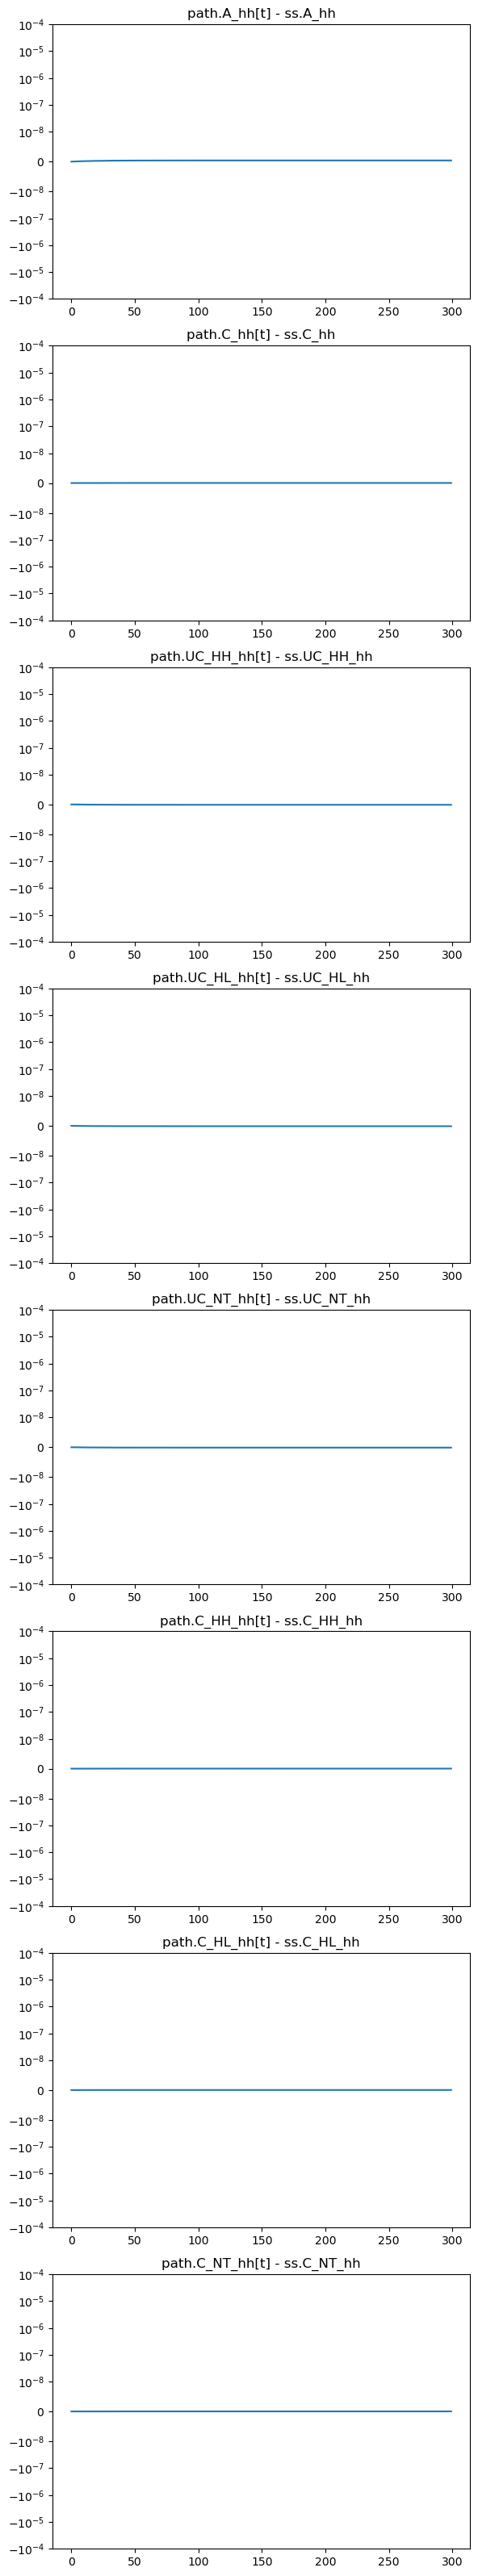

In [ ]:
# Verifies the EGM backward solution and distribution simulation are consistent
model.test_hh_path()

## 4. Jacobians

In [52]:
# Confirms the GE block sequence produces a valid Jacobian
# (this is the main computational step)
model.compute_jacs(do_print=True)

household Jacobians:
one step deviation from steady state calculated in 0.0 secs
curly_Y and curly_D calculated for beta            in 0.9 secs
curly_Y and curly_D calculated for inc_HH          in 1.0 secs
curly_Y and curly_D calculated for inc_HL          in 1.0 secs
curly_Y and curly_D calculated for inc_LH          in 1.0 secs
curly_Y and curly_D calculated for inc_LL          in 1.3 secs
curly_Y and curly_D calculated for inc_NT          in 1.3 secs
curly_Y and curly_D calculated for ra              in 1.3 secs
curly_E calculated in 1.4 secs
builiding blocks combined in 1.1 secs
household Jacobian computed in 10.3 secs

full Jacobians:
full Jacobian to unknowns computed in 13.2 secs [in evaluate_blocks(): 7.9 secs]
full Jacobian to shocks computed in 5.9 secs [in evaluate_blocks(): 3.6 secs]


# Emil test (alien brain)

In [ ]:
import numpy as np

from numpy.fft import fftn, rfftn

from numba import njit

 

def winding_criterion(A, N=4096):

    """Build path of det A(lambda) and obtain its winding number, implementing winding number

    criterion for determinacy that generalizes Onatski (2006).

 

    Parameters

    ----------

    A : array ((2T-1)*k*k)

            asymptotic H_U matrix, where A[t,i,j] gives Jacobian of target i vs. unknown j

            at t-(T-1) above the main diagonal

    N : [optional] int

            number of equispaced points lambda on interval [0,2pi] for evaluating det A(lambda)

 

    Returns

    ----------

    winding_number : int

            winding number that characterizes existence and uniqueness of solutions:

                0 for determinate solution

                -1 (or lower) for indeterminacy

                1 (or higher) for no solution

    """

    det_Alambda = detA_path(A, N)

    return winding_number(det_Alambda.real, det_Alambda.imag)

 

 

def detA_path(A, N=4096):

    """Evaluates det A(lambda) at N equispaced points lambda on interval [0,2pi].

 

    A brief derivation of how this function uses FFT to rapidly evaluate det A(lambda) follows.

 

    We have, letting A_(-j) denote the k*k matrix A[-j,:,:]:

 

        det A(lambda) = det sum_(j=-(T-1))^(T-1) A_(-j)e^(i*j*lambda)

   

    which, flipping the order and realigning j, can be rewritten as

 

        e^(lambda*i*k*(T-1)) det sum_(j=0)^(2T-2) A_(-j+(T-1))e^(-i*j*lambda)   (***)

 

    Taking the sum in (***) for the values lambda=0,2*pi/N,...,2*pi*(N-1)/N, assuming N >= (2T-1),

    is just taking the discrete Fourier transform of the sequence A_(T-1),...,A_(-(T-1)),0,...,0

    right-padded with zeros to length N.

   

    Hence we can rapidly, simultaneously evaluate (***) at all points lambda equispaced from lambda=0

    to lambda=2*pi using the FFT. This is implemented below, with additional efficiency from fact that

    A(lambda) and A(2*pi-lambda) are conjugate.

    """

    # preliminary: assume and verify shape 2*T-1, k, k for A

    T = (A.shape[0]+1) // 2

    k = A.shape[1]

    if not (T == (A.shape[0]+1)/2 and N >= 2*T-1 and k == A.shape[2]):

        raise ValueError(f'Asymptotic A matrix has improper shape {A.shape}')

 

    # step 1: use FFT to calculate A(lambda) for each lambda = 2*pi*{0, 1/N, ..., 1/2} (last if N even)

    # note that we need to reverse order of A_t to get sequence A_(T-1),...,A_(-(T-1)),0,...,0

    Alambda = rfftn(A[::-1,...], axes=(0,), s=(N,))

 

    # step 2: take determinant of each, then multiply by e^(i*k*(T-1)*lambda) to get (***)

    det_Alambda = np.empty(N+1, dtype=np.complex128)

    det_Alambda[:N//2+1] = np.linalg.det(Alambda)*np.exp(2j*np.pi*k*(T-1)/N*np.arange(N//2+1))

   

    # step 3: use conjugate symmetry to fill in rest

    det_Alambda[N//2+1:] = det_Alambda[:(N+1)//2][::-1].conj()

 

    return det_Alambda

 

 

@njit

def winding_number(x, y):

    """Compute winding number around origin of (x,y) coordinates that make closed path by

    counting number of counterclockwise crossings of ray from (0,0) -> (infty,0) on x axis"""

    # ensure closed path!

    assert x[-1] == x[0] and y[-1] == y[0]

 

    winding_number = 0

 

    # we iterate through coordinates (x[i], y[i]), where cur_sign is flag for

    # whether current coordinate is above the x axis

    cur_sign = (y[0] >= 0)

    for i in range(1, len(x)):

        if (y[i] >= 0) != cur_sign:

            # if we're here, this means the x axis has been crossed

            # this generally happens rarely, so efficiency no biggie

            cur_sign = (y[i] >= 0)

           

            # crossing of x axis implies possible crossing of ray (0,0) -> (infty,0)

            # we will evaluate three possible cases to see if this is indeed the case

            if x[i] > 0 and x[i-1] > 0:

                # case 1: both (x[i-1],y[i-1]) and (x[i],y[i]) on right half-plane, definite crossing

                # increment winding number if counterclockwise (negative to positive y)

                # decrement winding number if clockwise (positive to negative y)

                winding_number += 2*cur_sign-1

            elif not (x[i] <= 0 and x[i-1] <= 0):

                # here we've ruled out case 2: both (x[i-1],y[i-1]) and (x[i],y[i]) in left

                # half-plane, where there is definitely no crossing

 

                # thus we're in ambiguous case 3, where points (x[i-1],y[i-1]) and (x[i],y[i]) in

                # different half-planes: here we must analytically check whether we crossed

                # x-axis to the right or the left of the origin

                # [this step is intended to be rare]

                cross_coord = (x[i-1]*y[i] - x[i]*y[i-1])/(y[i]-y[i-1])

                if cross_coord > 0:

                    winding_number += 2*cur_sign-1

    return winding_number

 



In [ ]:
k = len(model.unknowns)   # = len(model.targets)
T = model.par.T
t_ref = T // 2            # interior time — avoids boundary effects, gives both +/- lags

max_lag   = min(t_ref, T - 1 - t_ref)
T_asym    = max_lag + 1   # lags run from -(T_asym-1) to +(T_asym-1)

A = np.zeros((2*T_asym - 1, k, k))
for d in range(-(T_asym-1), T_asym):
    s = t_ref + d          # unknown time index for this diagonal
    A[T_asym-1+d] = model.H_U[t_ref::T, s::T]

wn = winding_criterion(A)
print(f'Winding number: {wn}')

Winding number: -3


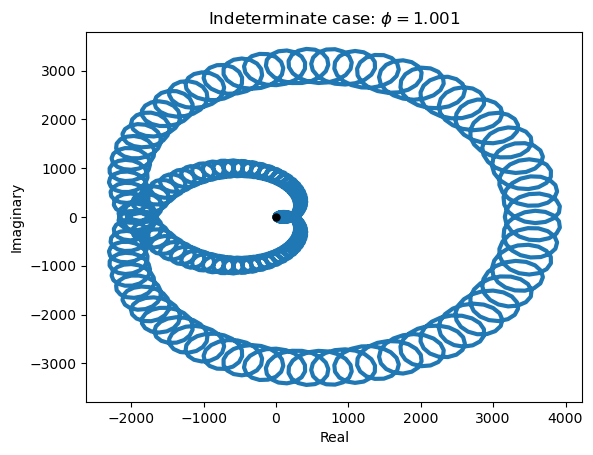

In [ ]:
phi = 1.001

#ss_cur = {**ss, 'phi': phi}

#A_cur = jac.get_H_U(block_list, unknowns, targets, T, ss_cur,

#                    asymptotic=True, use_saved=True)

 

det_Alambda = detA_path(A)

x, y = det_Alambda.real, det_Alambda.imag

 

# plot curve

plt.plot(x, y, label=r'$\det A(\lambda)$', linewidth=3);

 

# dot for origin

plt.plot(0, 0, marker='o', markersize=5, color="black")

 

# arrow to show orientation (using rate of change around lambda=0)

plt.arrow(x[0], y[0], 0.001*(x[1]-x[-2]), 0.001*(y[1]-y[-2]), color='C0',

          width=0.0001, head_width=0.05, head_length=0.08)

plt.title(r'Indeterminate case: $\phi=1.001$')

plt.xlabel(r'Real')

plt.ylabel(r'Imaginary');

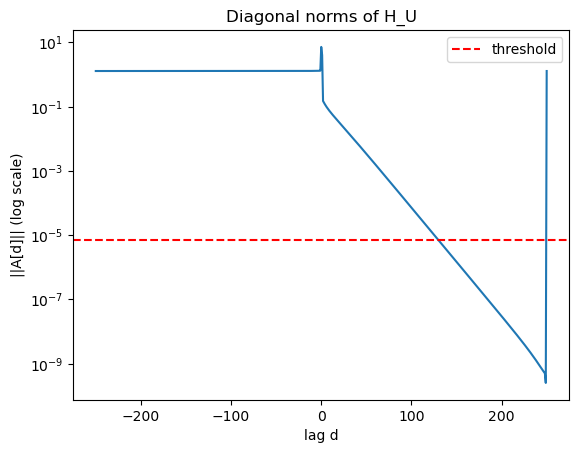

In [ ]:
k = len(model.unknowns)
T = model.par.T
t_ref = T // 2

diag_norms = [np.linalg.norm(model.H_U[t_ref::T, (t_ref+d)::T]) 
              for d in range(-(T//2), T//2+1)]

plt.figure()
plt.semilogy(range(-(T//2), T//2+1), diag_norms)
plt.axhline(1e-6 * max(diag_norms), color='r', linestyle='--', label='threshold')
plt.xlabel('lag d')
plt.ylabel('||A[d]|| (log scale)')
plt.title('Diagonal norms of H_U')
plt.legend()

Text(0.5, 1.0, 'Norm at lag d=-100 vs reference point')

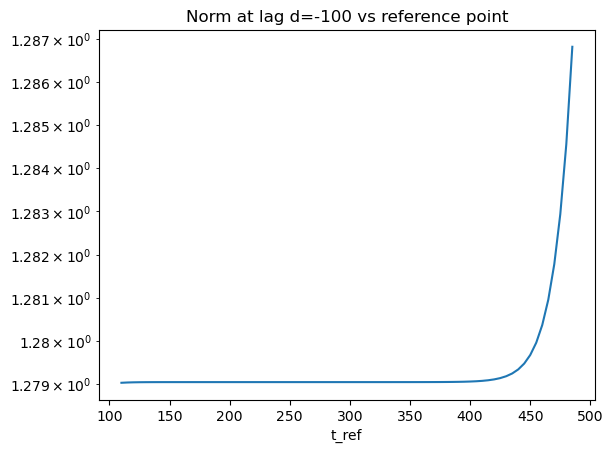

In [ ]:
# Check if the negative-lag plateau disappears with a different t_ref
d = -100
norms_vs_tref = [np.linalg.norm(model.H_U[tr::T, (tr+d)::T]) 
                 for tr in range(abs(d)+10, T-10, 5)]
plt.semilogy(range(abs(d)+10, T-10, 5), norms_vs_tref)
plt.xlabel('t_ref')
plt.title(f'Norm at lag d={d} vs reference point')


# Import vs. export shcok

In [53]:
TARIFF_SIZE = 0.01   # 25% tariff
TARIFF_RHO  = 0.95   # persistence

In [54]:
m_tau_x = model.copy()

m_tau_x.par.jump_tau_x = TARIFF_SIZE
m_tau_x.par.rho_tau_x  = TARIFF_RHO

m_tau_x.find_transition_path(shocks=['tau_x'], do_print=False, do_end_check=True)


E_us: terminal value is   0.99899142, but ss value is   1.00000000
CB_us: terminal value is   0.99899142, but ss value is   1.00000000
PM_us_us: terminal value is   1.00101931, but ss value is   1.00000000
PM_us_eu: terminal value is   1.00101931, but ss value is   1.00000000
PM_us: terminal value is   1.00101931, but ss value is   1.00000000
PF_us_s: terminal value is   1.00101931, but ss value is   1.00000000
W_us: terminal value is   1.00101931, but ss value is   1.00000000
PTH_us_s: terminal value is   1.00101930, but ss value is   1.00000000
NX: terminal value is   0.00000002, but ss value is   0.00000000
CA: terminal value is   0.00000002, but ss value is   0.00000000
NFA: terminal value is  -0.00000018, but ss value is   0.00000000


In [55]:
m_tau_m = model.copy()
m_tau_m.par.jump_tau_m = TARIFF_SIZE
m_tau_m.par.rho_tau_m  = TARIFF_RHO

m_tau_m.find_transition_path(shocks=['tau_m'], do_print=False, do_end_check=False)

In [56]:
m_war = model.copy()
m_war.par.jump_tau_x = TARIFF_SIZE
m_war.par.rho_tau_x  = TARIFF_RHO
m_war.par.jump_tau_m = TARIFF_SIZE
m_war.par.rho_tau_m  = TARIFF_RHO

m_war.find_transition_path(shocks=['tau_x', 'tau_m'], do_print=False, do_end_check=False)

### shocks ###


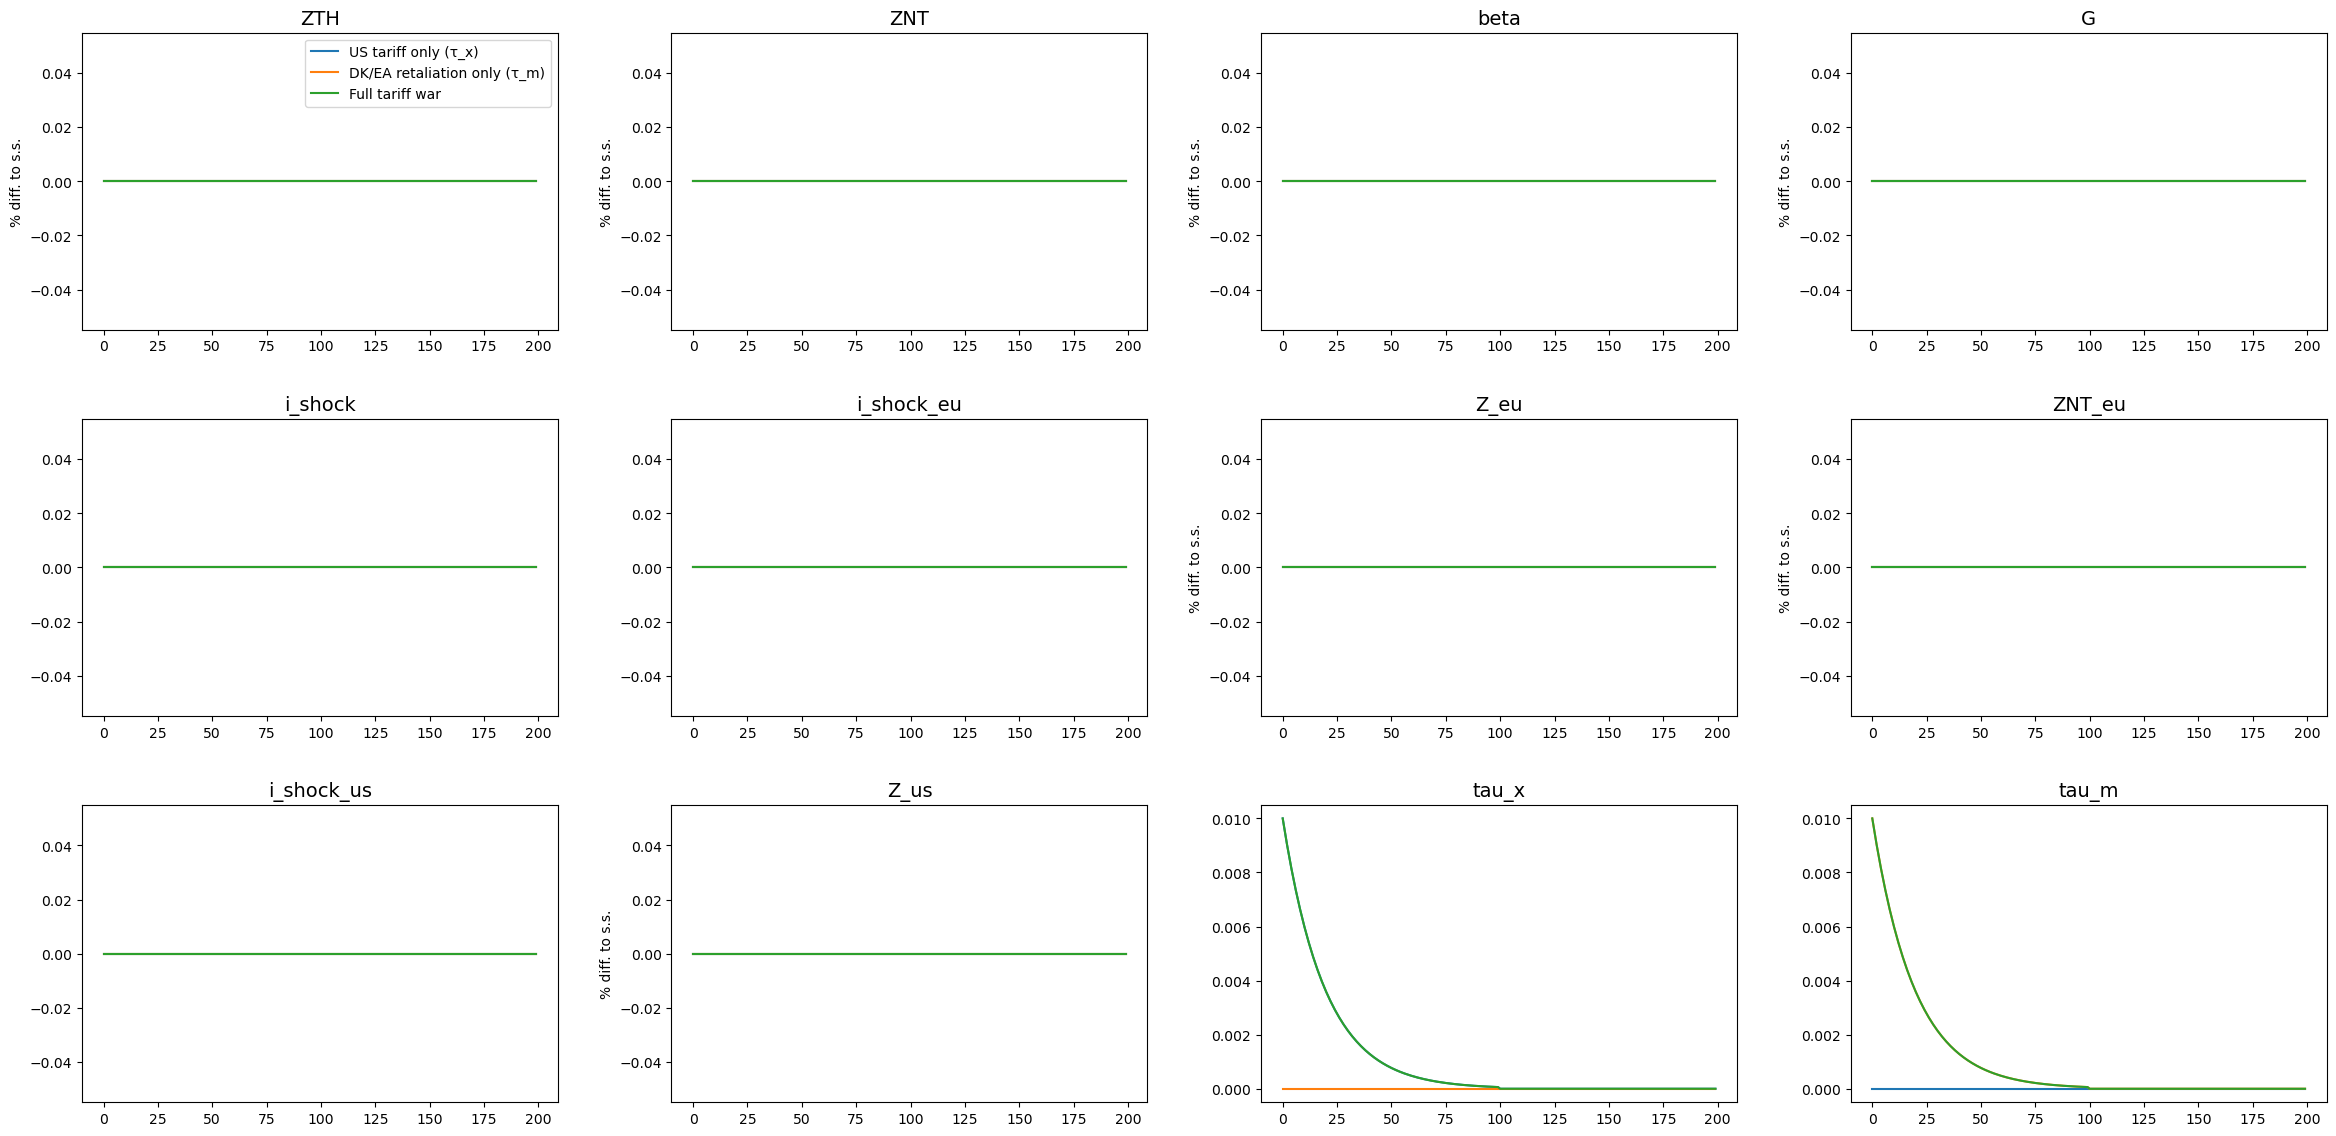


### varnames ###


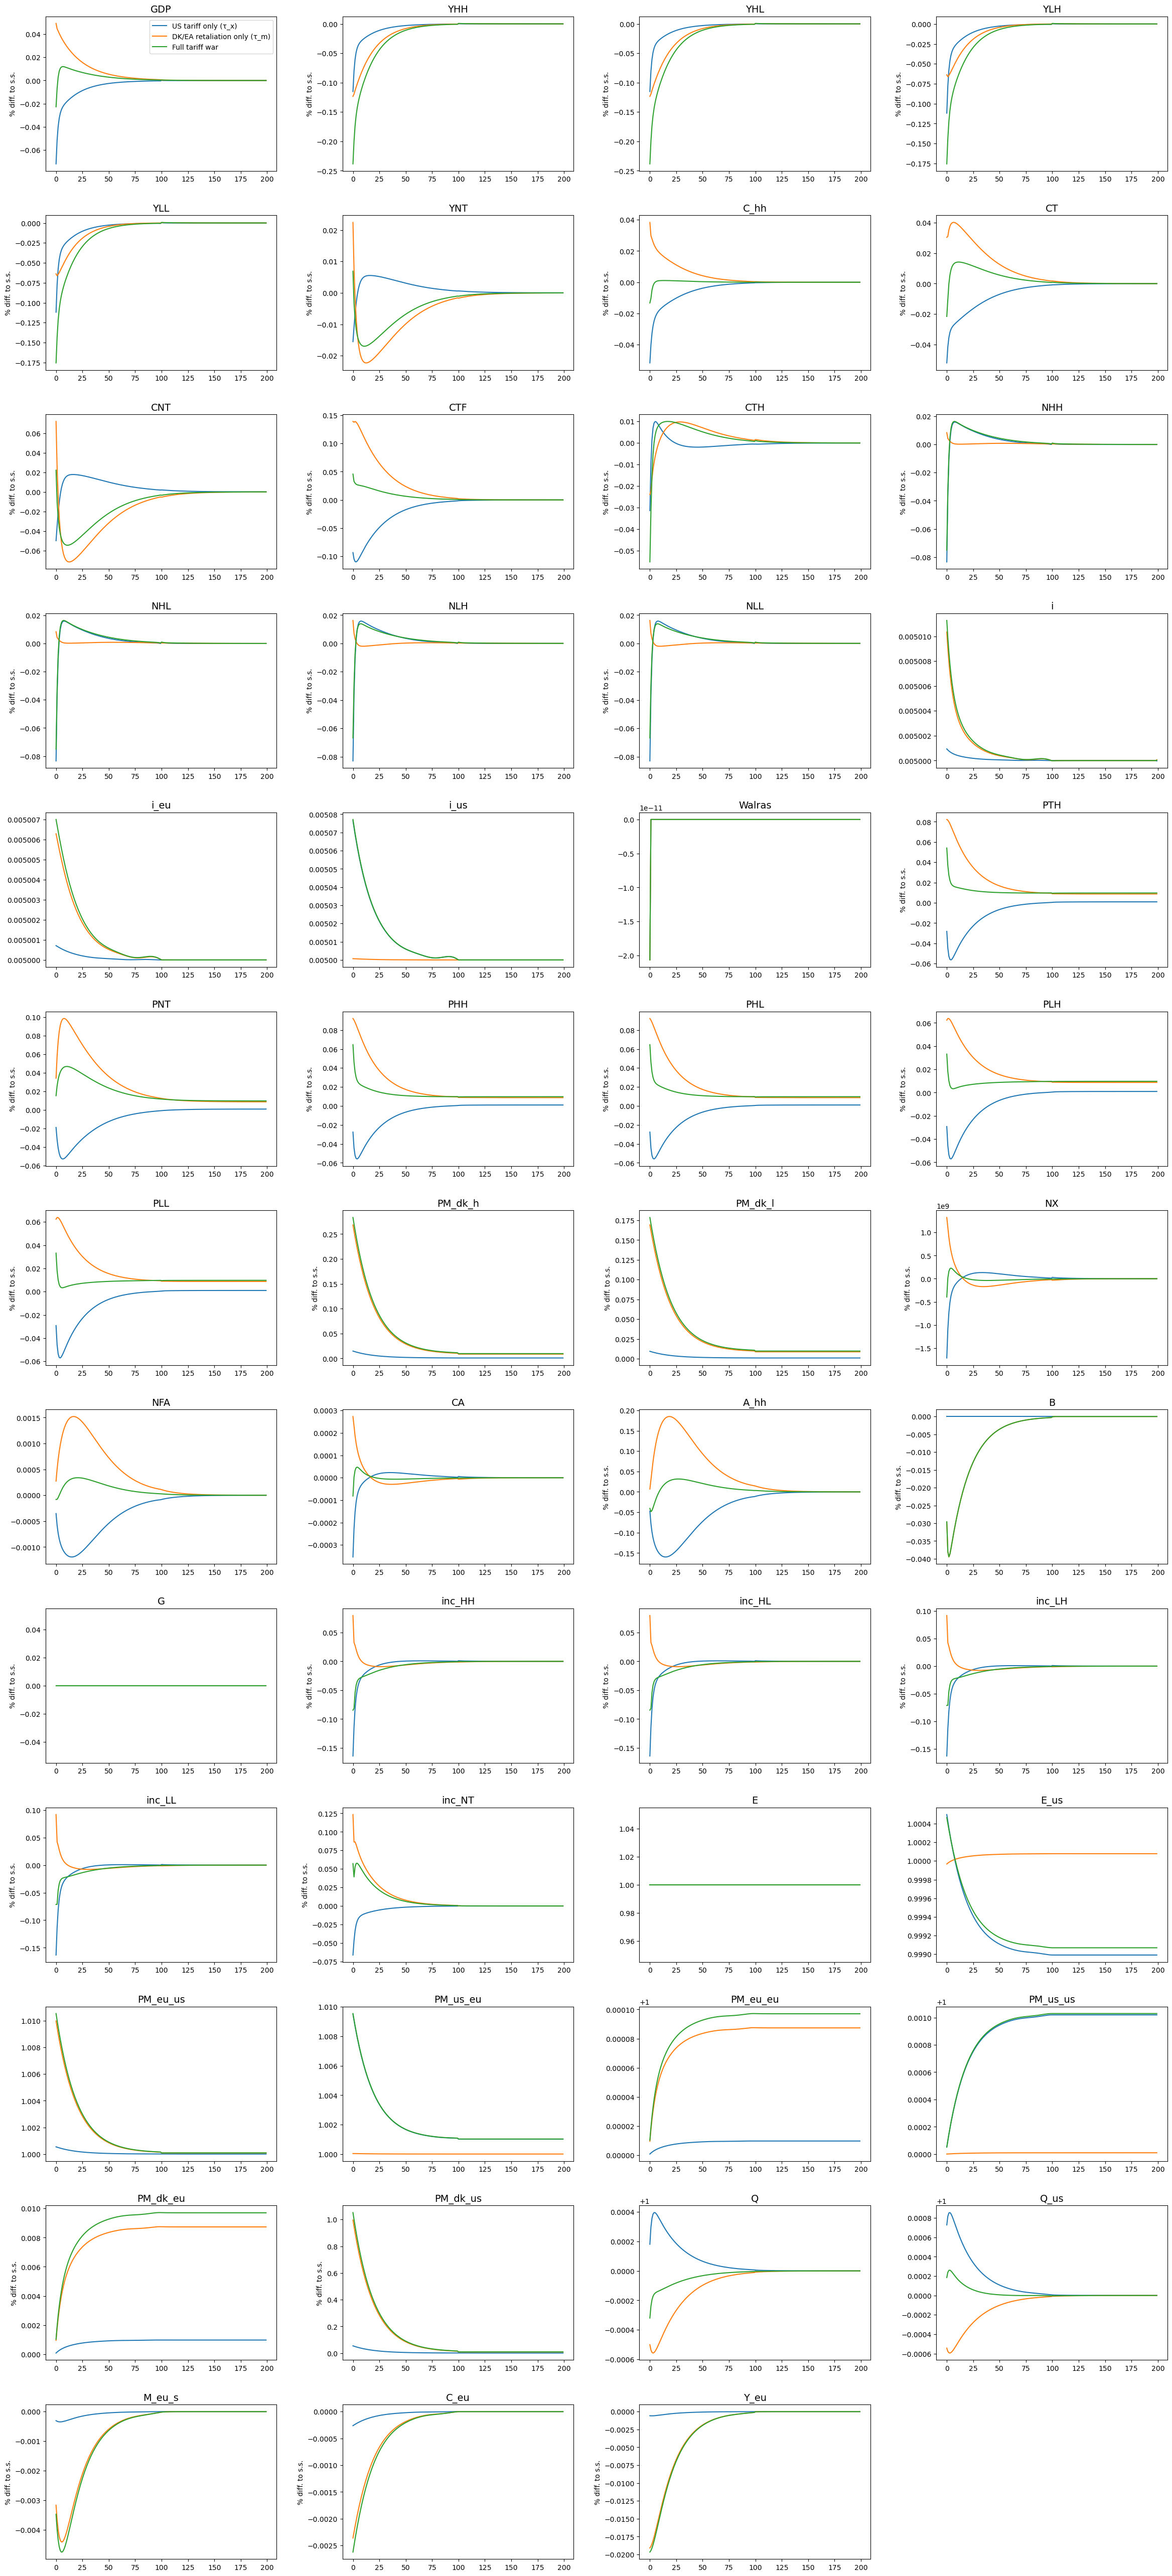


### tagets ###


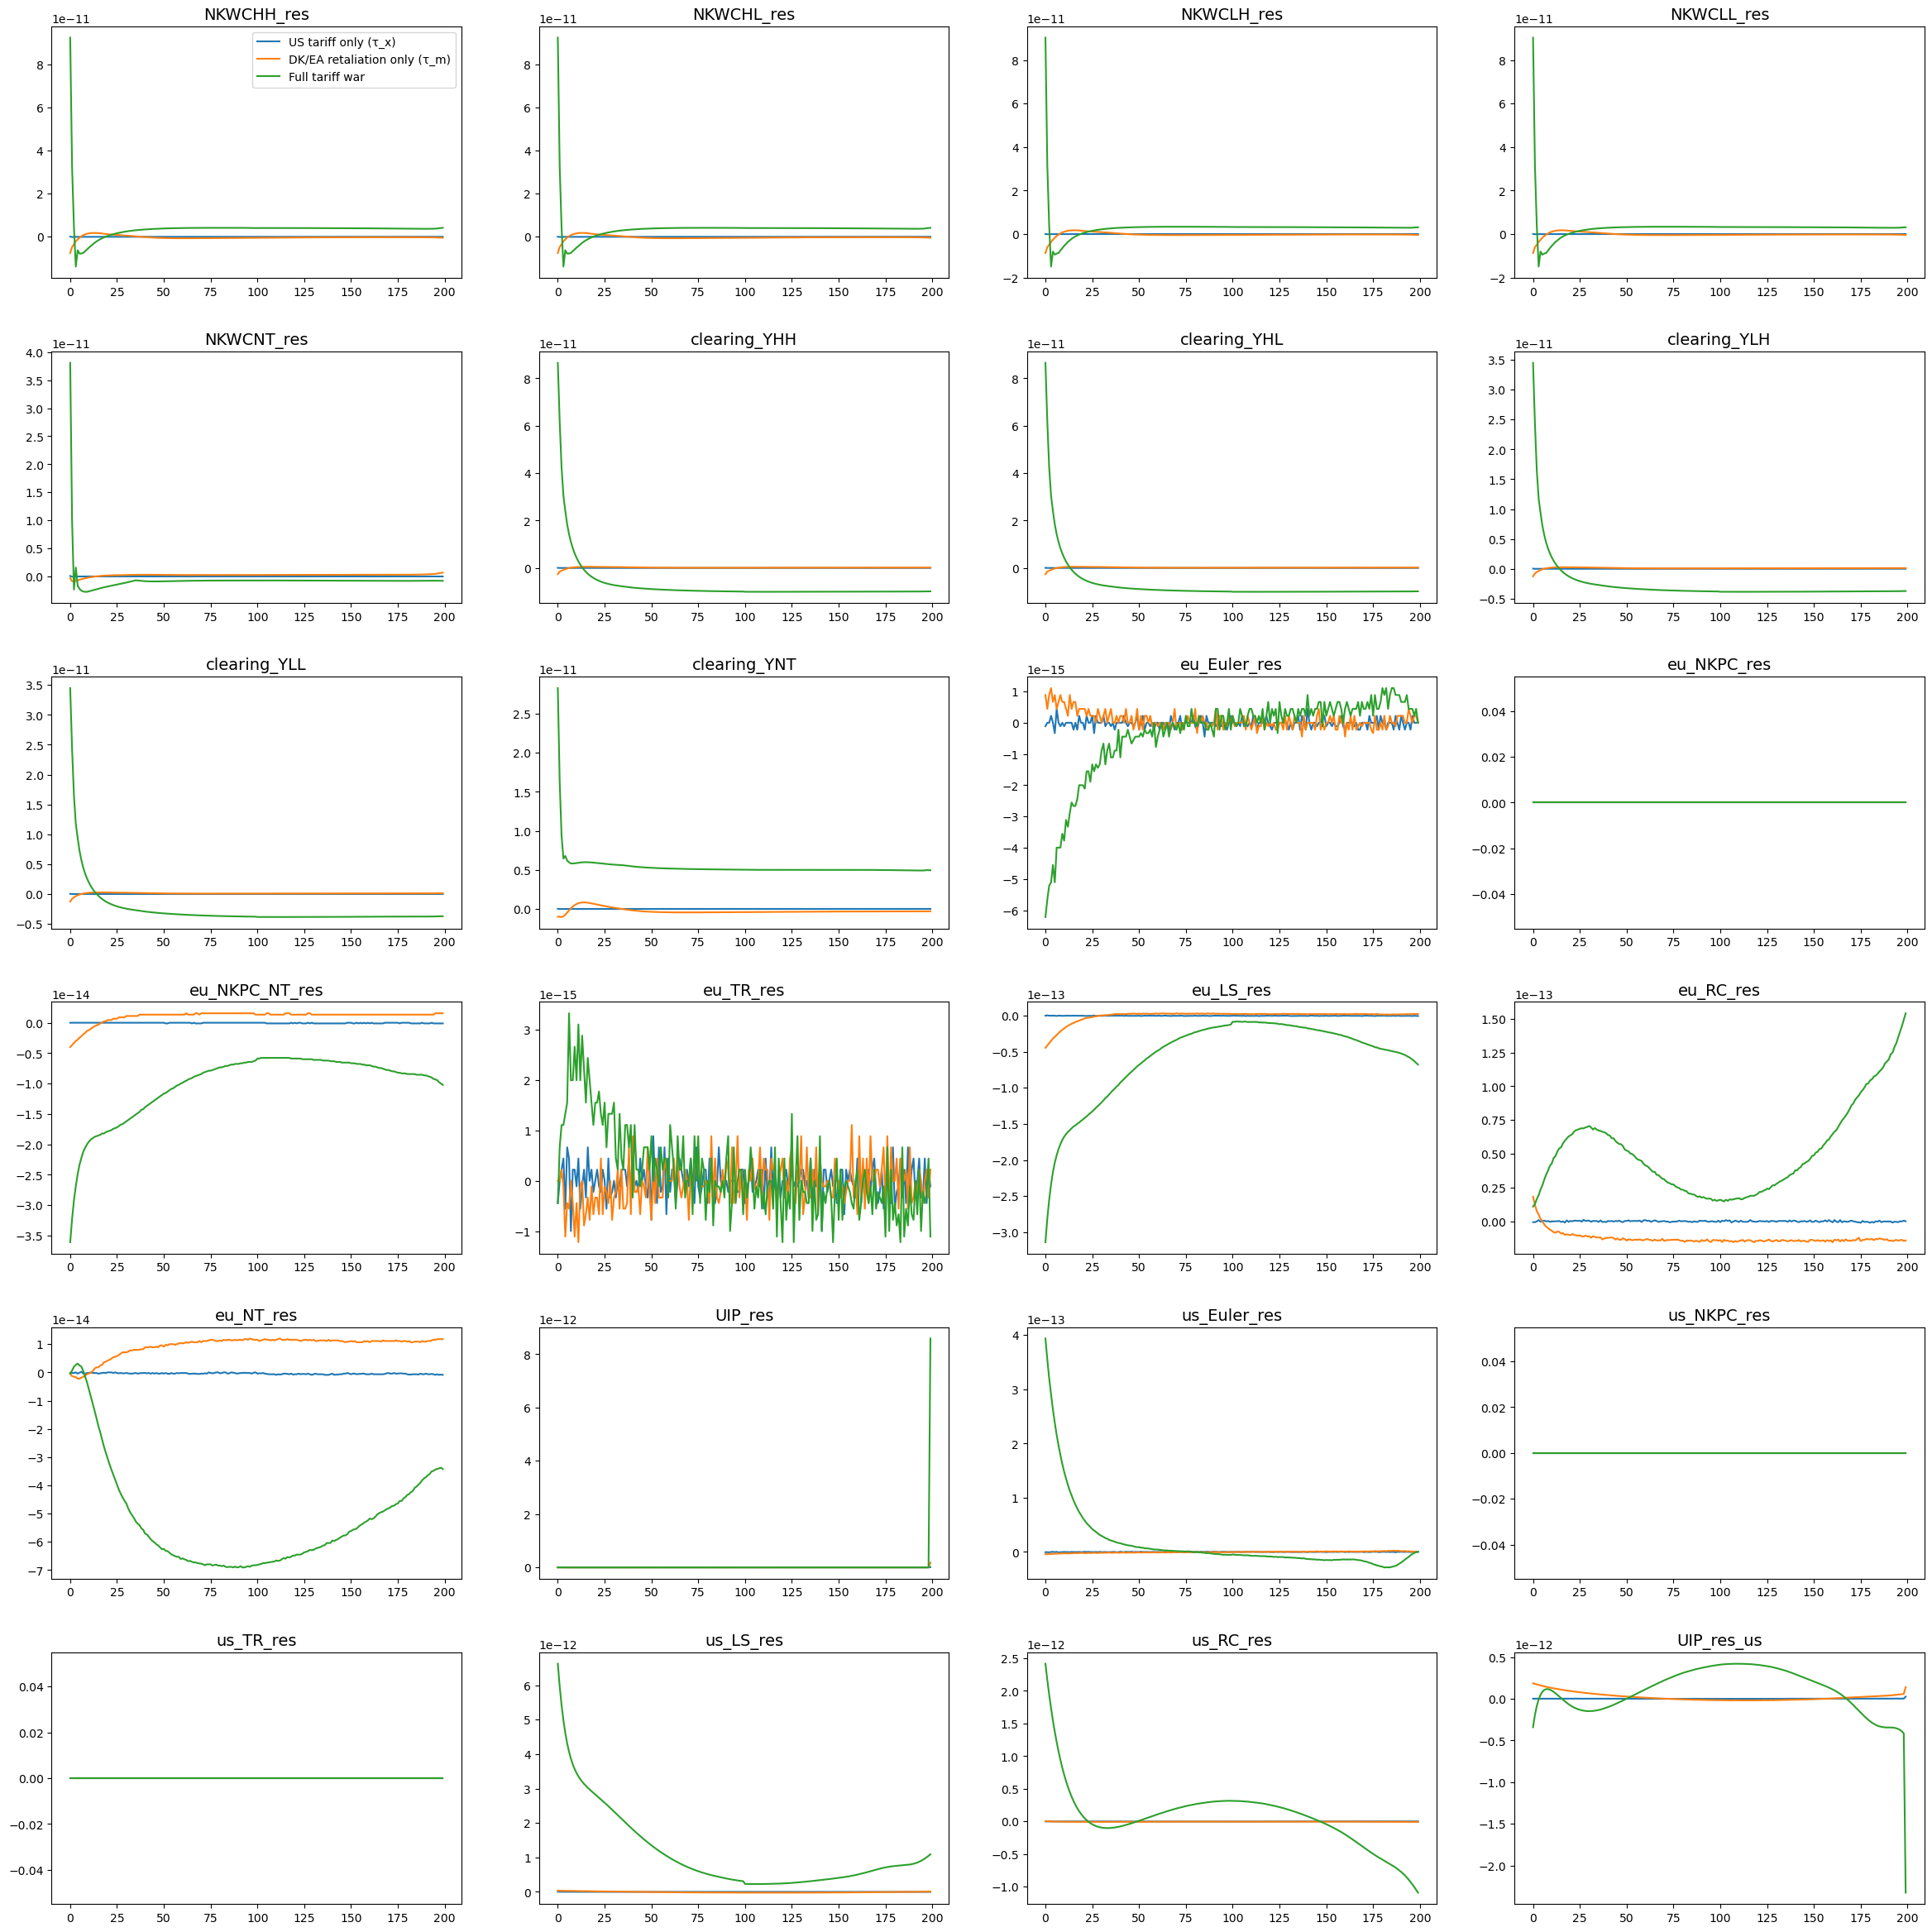

<Figure size 640x480 with 0 Axes>

In [57]:
# Variables shown in levels (rates and prices — not log-deviations)
lvl_value = ['pi', 'pi_eu', 'pi_us', 'tau', 'r', 'ra', 'i', 'i_eu', 'i_us',
             'tau_m', 'tau_x', 'E', 'E_us', 'NFA', 'Walras', 'PM_eu_us', 'PM_us_eu', 'PM_eu_eu', 'PM_us_us', 'Q', 'Q_us',
             'i_shock_us', 'i_shock_eu', 'i_shock', 'CA']

# Models and labels for comparison
models = [m_tau_x, m_tau_m, m_war]
labels = ['US tariff only (τ_x)', 'DK/EA retaliation only (τ_m)', 'Full tariff war']

model.compare_IRFs(
    models, labels,
    varnames=['GDP', 'YHH', 'YHL', 'YLH', 'YLL', 'YNT', 'C_hh', 'CT', 'CNT', 'CTF', 'CTH', 'NHH', 'NHL', 'NLH', 'NLL', 'i', 'i_eu', 'i_us', 'Walras',
               'PTH', 'PNT', 'PHH', 'PHL', 'PLH', 'PLL', 'PM_dk_h', 'PM_dk_l', 'NX', 'NFA', 'CA', 'A_hh', 'B', 'G', 'inc_HH', 'inc_HL', 'inc_LH', 'inc_LL', 'inc_NT',
                'E', 'E_us', 'PM_eu_us', 'PM_us_eu', 'PM_eu_eu', 'PM_us_us', 'PM_dk_eu', 'PM_dk_us', 'Q', 'Q_us',
                'M_eu_s', 'C_eu', 'Y_eu'],
    lvl_value=lvl_value,
    T_max=200, ncols=4,
    do_targets=True
)
plt.suptitle('Output and consumption', y=1.02)
plt.tight_layout()
#plt.savefig(os.path.join(folder, 'output_consumption.png'), dpi=150, bbox_inches='tight')

## Import and Export shock

In [ ]:

par.jump_tau_m = 0.05   # +5pp US tariff on DK/EA imports
par.rho_tau_m  = 0.80
par.jump_tau_x = 0.05   # +5pp US tariff on DK/EA imports
par.rho_tau_x  = 0.80

model.find_transition_path(shocks=['tau_m', 'tau_x'], do_print=True, do_end_check=True)

finding the transition path:
 it =   0 -> max. abs. error = 1.26e-02
   5.27e-04 in NKWCHH_res
   5.27e-04 in NKWCHL_res
   5.27e-04 in NKWCNT_res
   1.26e-02 in clearing_YHH
   6.40e-03 in clearing_YHL
   1.55e-03 in clearing_YNT
   0.00e+00 in eu_Euler_res
   0.00e+00 in eu_NKPC_res
   0.00e+00 in eu_TR_res
   5.35e-04 in eu_LS_res
   5.35e-04 in eu_RC_res
   2.22e-16 in UIP_res
   0.00e+00 in us_Euler_res
   0.00e+00 in us_NKPC_res
   0.00e+00 in us_TR_res
   4.80e-03 in us_LS_res
   4.80e-03 in us_RC_res
   9.59e-03 in UIP_res_us
 it =   1 -> max. abs. error = 7.46e-04
   5.70e-04 in NKWCHH_res
   5.74e-04 in NKWCHL_res
   1.76e-05 in NKWCNT_res
   7.46e-04 in clearing_YHH
   4.06e-04 in clearing_YHL
   1.07e-04 in clearing_YNT
   6.46e-09 in eu_Euler_res
   5.64e-18 in eu_NKPC_res
   8.67e-19 in eu_TR_res
   4.44e-06 in eu_LS_res
   4.46e-06 in eu_RC_res
   5.36e-05 in UIP_res
   6.96e-06 in us_Euler_res
   4.58e-17 in us_NKPC_res
   6.94e-18 in us_TR_res
   1.28e-05 in us_LS_res


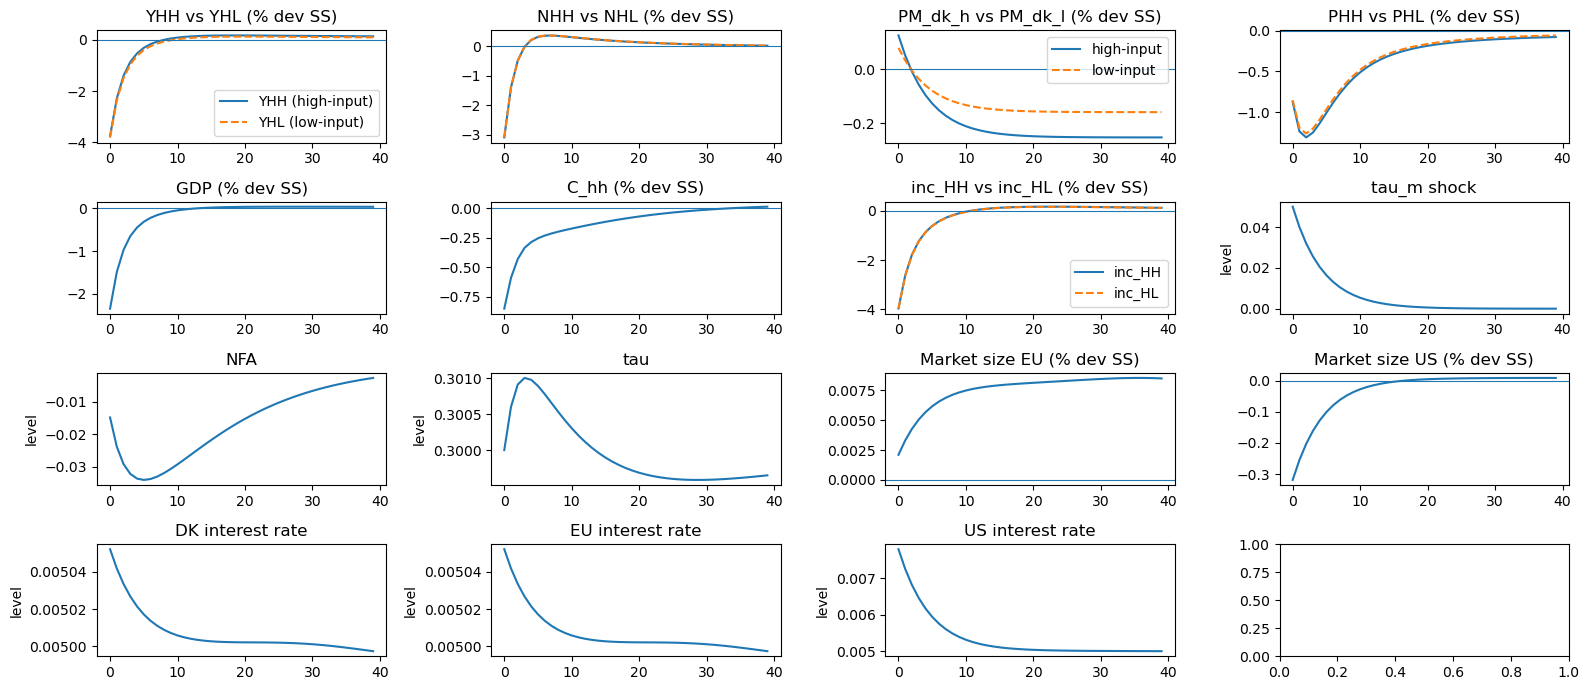

High-input sector hit harder: NO — check extension


In [ ]:
path = model.path
T_plot = 40
t = np.arange(T_plot)

fig, axes = plt.subplots(4, 4, figsize=(16, 7))

def pct(x, x_ss):
    return (x[:T_plot] / x_ss - 1) * 100

# Row 1: Production side
axes[0,0].set_title('YHH vs YHL (% dev SS)')
axes[0,0].plot(t, pct(path.YHH, ss.YHH), label='YHH (high-input)')
axes[0,0].plot(t, pct(path.YHL, ss.YHL), label='YHL (low-input)', ls='--')
axes[0,0].legend(); axes[0,0].axhline(0, lw=0.8)

axes[0,1].set_title('NHH vs NHL (% dev SS)')
axes[0,1].plot(t, pct(path.NHH, ss.NHH))
axes[0,1].plot(t, pct(path.NHL, ss.NHL), ls='--')
axes[0,1].axhline(0, lw=0.8)

axes[0,2].set_title('PM_dk_h vs PM_dk_l (% dev SS)')
axes[0,2].plot(t, pct(path.PM_dk_h, ss.PM_dk_h), label='high-input')
axes[0,2].plot(t, pct(path.PM_dk_l, ss.PM_dk_l), label='low-input', ls='--')
axes[0,2].legend(); axes[0,2].axhline(0, lw=0.8)

axes[0,3].set_title('PHH vs PHL (% dev SS)')
axes[0,3].plot(t, pct(path.PHH, ss.PHH))
axes[0,3].plot(t, pct(path.PHL, ss.PHL), ls='--')
axes[0,3].axhline(0, lw=0.8)

# Row 2: Aggregate
axes[1,0].set_title('GDP (% dev SS)')
axes[1,0].plot(t, pct(path.GDP, ss.GDP))
axes[1,0].axhline(0, lw=0.8)

axes[1,1].set_title('C_hh (% dev SS)')
axes[1,1].plot(t, pct(path.C_hh, ss.C_hh))
axes[1,1].axhline(0, lw=0.8)

axes[1,2].set_title('inc_HH vs inc_HL (% dev SS)')
axes[1,2].plot(t, pct(path.inc_HH, ss.inc_HH), label='inc_HH')
axes[1,2].plot(t, pct(path.inc_HL, ss.inc_HL), label='inc_HL', ls='--')
axes[1,2].legend(); axes[1,2].axhline(0, lw=0.8)

axes[1,3].set_title('tau_m shock')
axes[1,3].plot(t, path.tau_m[:T_plot])
axes[1,3].set_ylabel('level')

#Row 3
axes[2,0].set_title('NFA')
axes[2,0].plot(t, path.NFA[:T_plot])
axes[2,0].set_ylabel('level')

axes[2,1].set_title('tau')
axes[2,1].plot(t, path.tau[:T_plot])
axes[2,1].set_ylabel('level')

axes[2,2].set_title('Market size EU (% dev SS)')
axes[2,2].plot(t, pct(path.M_eu_s, ss.M_eu_s))
axes[2,2].axhline(0, lw=0.8)

axes[2,3].set_title('Market size US (% dev SS)')
axes[2,3].plot(t, pct(path.M_us_s, ss.M_us_s))
axes[2,3].axhline(0, lw=0.8)

#Row 4
axes[3,0].set_title('DK interest rate')
axes[3,0].plot(t, path.i[:T_plot])
axes[3,0].set_ylabel('level')

axes[3,1].set_title('EU interest rate')
axes[3,1].plot(t, path.i_eu[:T_plot])
axes[3,1].set_ylabel('level')

axes[3,2].set_title('US interest rate')
axes[3,2].plot(t, path.i_us[:T_plot])
axes[3,2].set_ylabel('level')


fig.tight_layout()
plt.show()

# Sector asymmetry check: high-input sector should be hit harder
dY_HH = pct(path.YHH, ss.YHH)[0]
dY_HL = pct(path.YHL, ss.YHL)[0]
#print(f'Impact on YHH: {dY_HH:.4f}%')
#print(f'Impact on YHL: {dY_HL:.4f}%')
asymmetry_ok = dY_HH < dY_HL   # high-input sector hurt more
print(f'High-input sector hit harder: {"YES (as expected)" if asymmetry_ok else "NO — check extension"}')

# Float exchange rate

In [ ]:
model_float = model.copy()
model_float.par.float = True
model_float.find_ss()
model_float.compute_jacs()

## tau_x shock

In [ ]:
mf_tau_x = model_float.copy()
mf_tau_x.par.jump_tau_x = TARIFF_SIZE
mf_tau_x.par.rho_tau_x  = TARIFF_RHO

mf_tau_x.find_transition_path(shocks=['tau_x'], do_print=False, do_end_check=False)

In [ ]:
mf_tau_m = model_float.copy()
mf_tau_m.par.jump_tau_m = TARIFF_SIZE
mf_tau_m.par.rho_tau_m  = TARIFF_RHO

mf_tau_m.find_transition_path(shocks=['tau_m'], do_print=False, do_end_check=False)

In [ ]:
mf_war = model_float.copy()
mf_war.par.jump_tau_x = TARIFF_SIZE
mf_war.par.rho_tau_x  = TARIFF_RHO
mf_war.par.jump_tau_m = TARIFF_SIZE
mf_war.par.rho_tau_m  = TARIFF_RHO

mf_war.find_transition_path(shocks=['tau_x', 'tau_m'], do_print=False, do_end_check=False)

### shocks ###


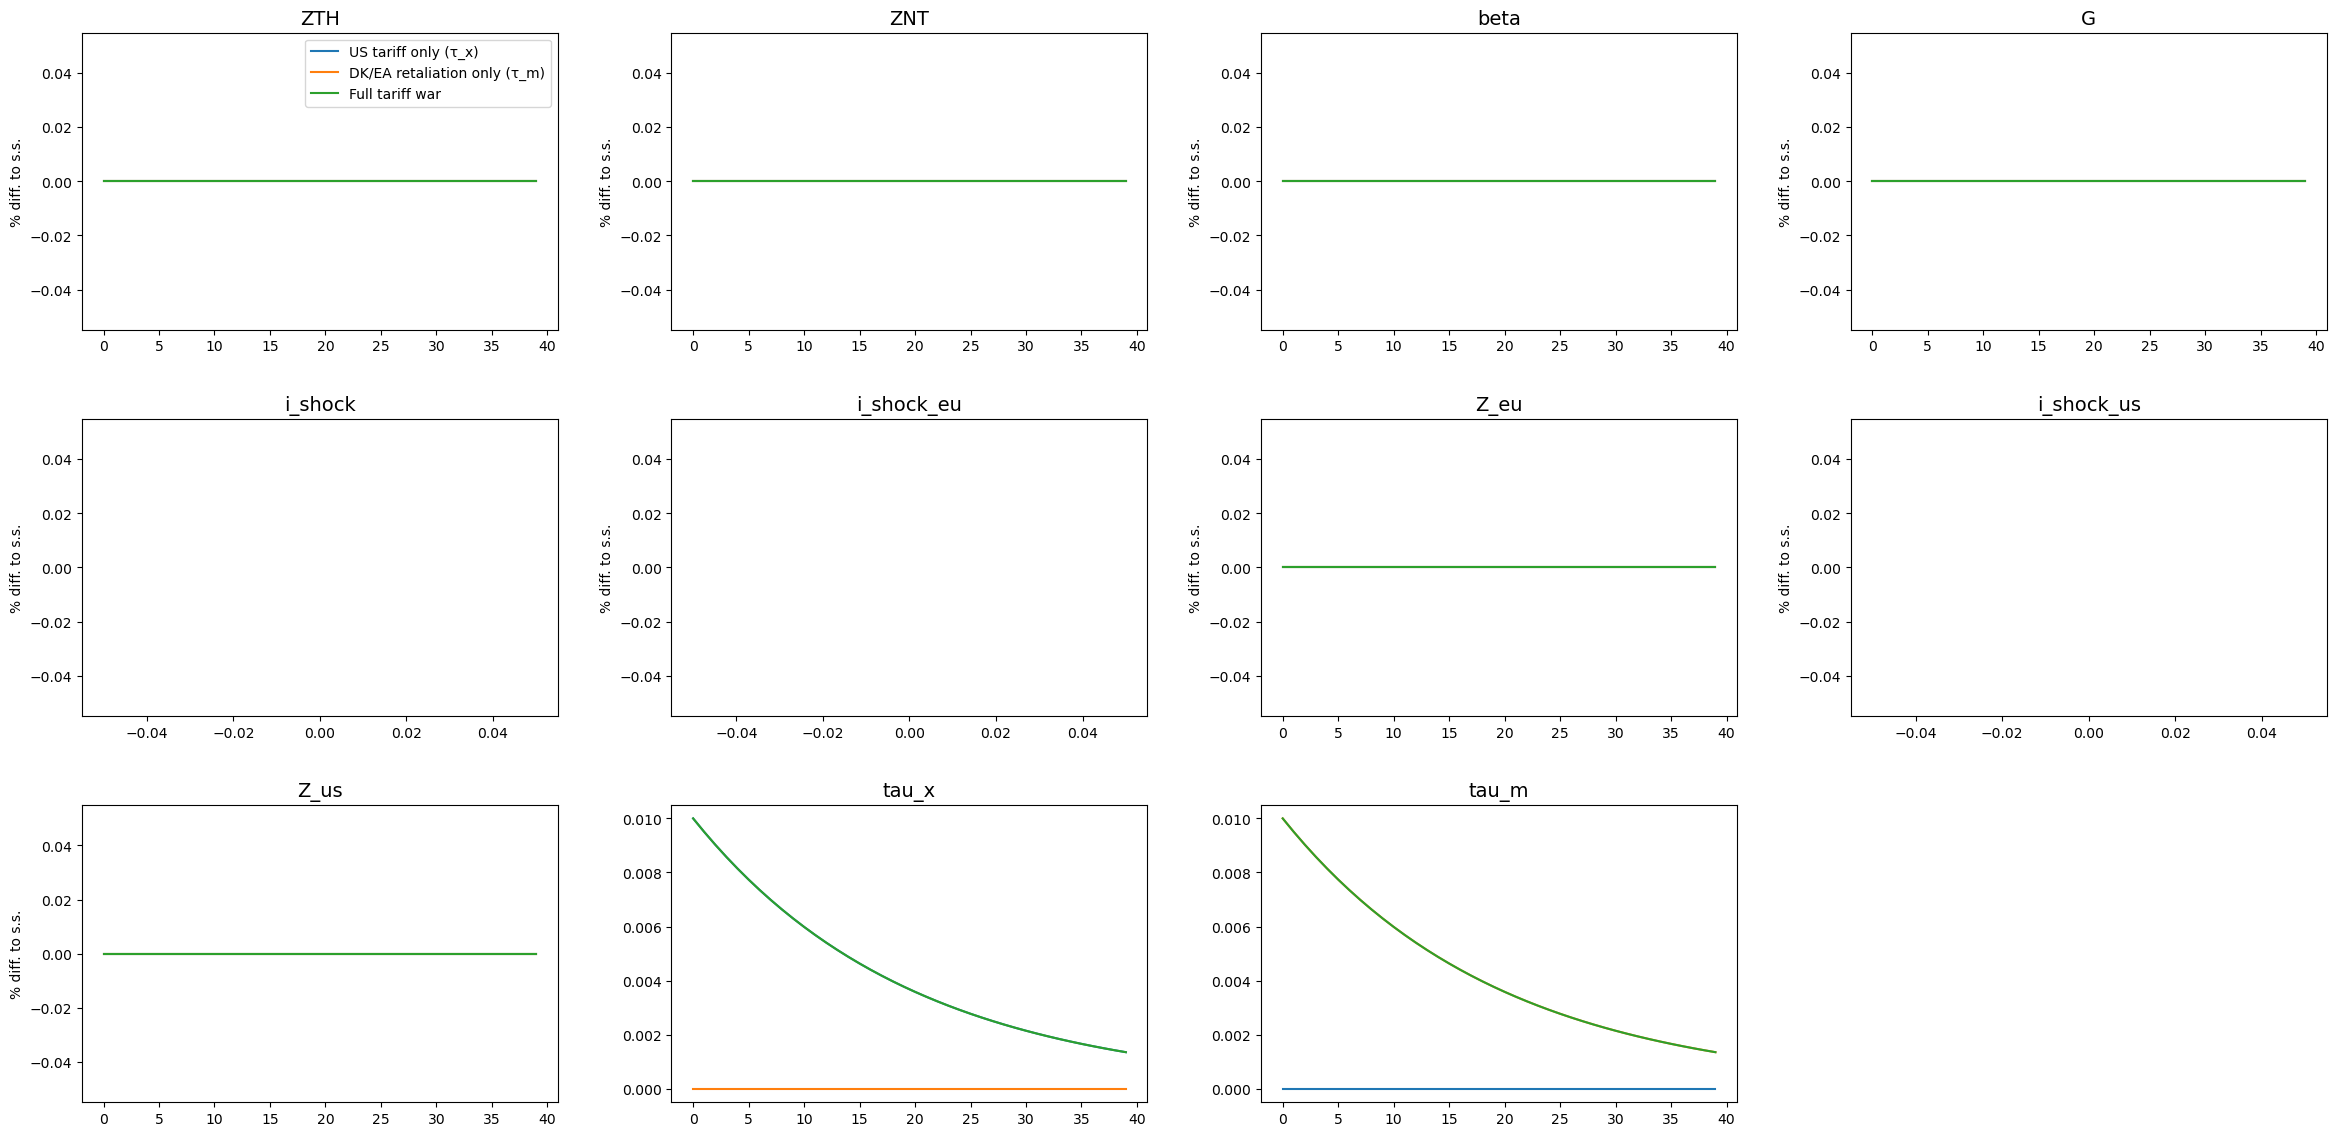


### varnames ###


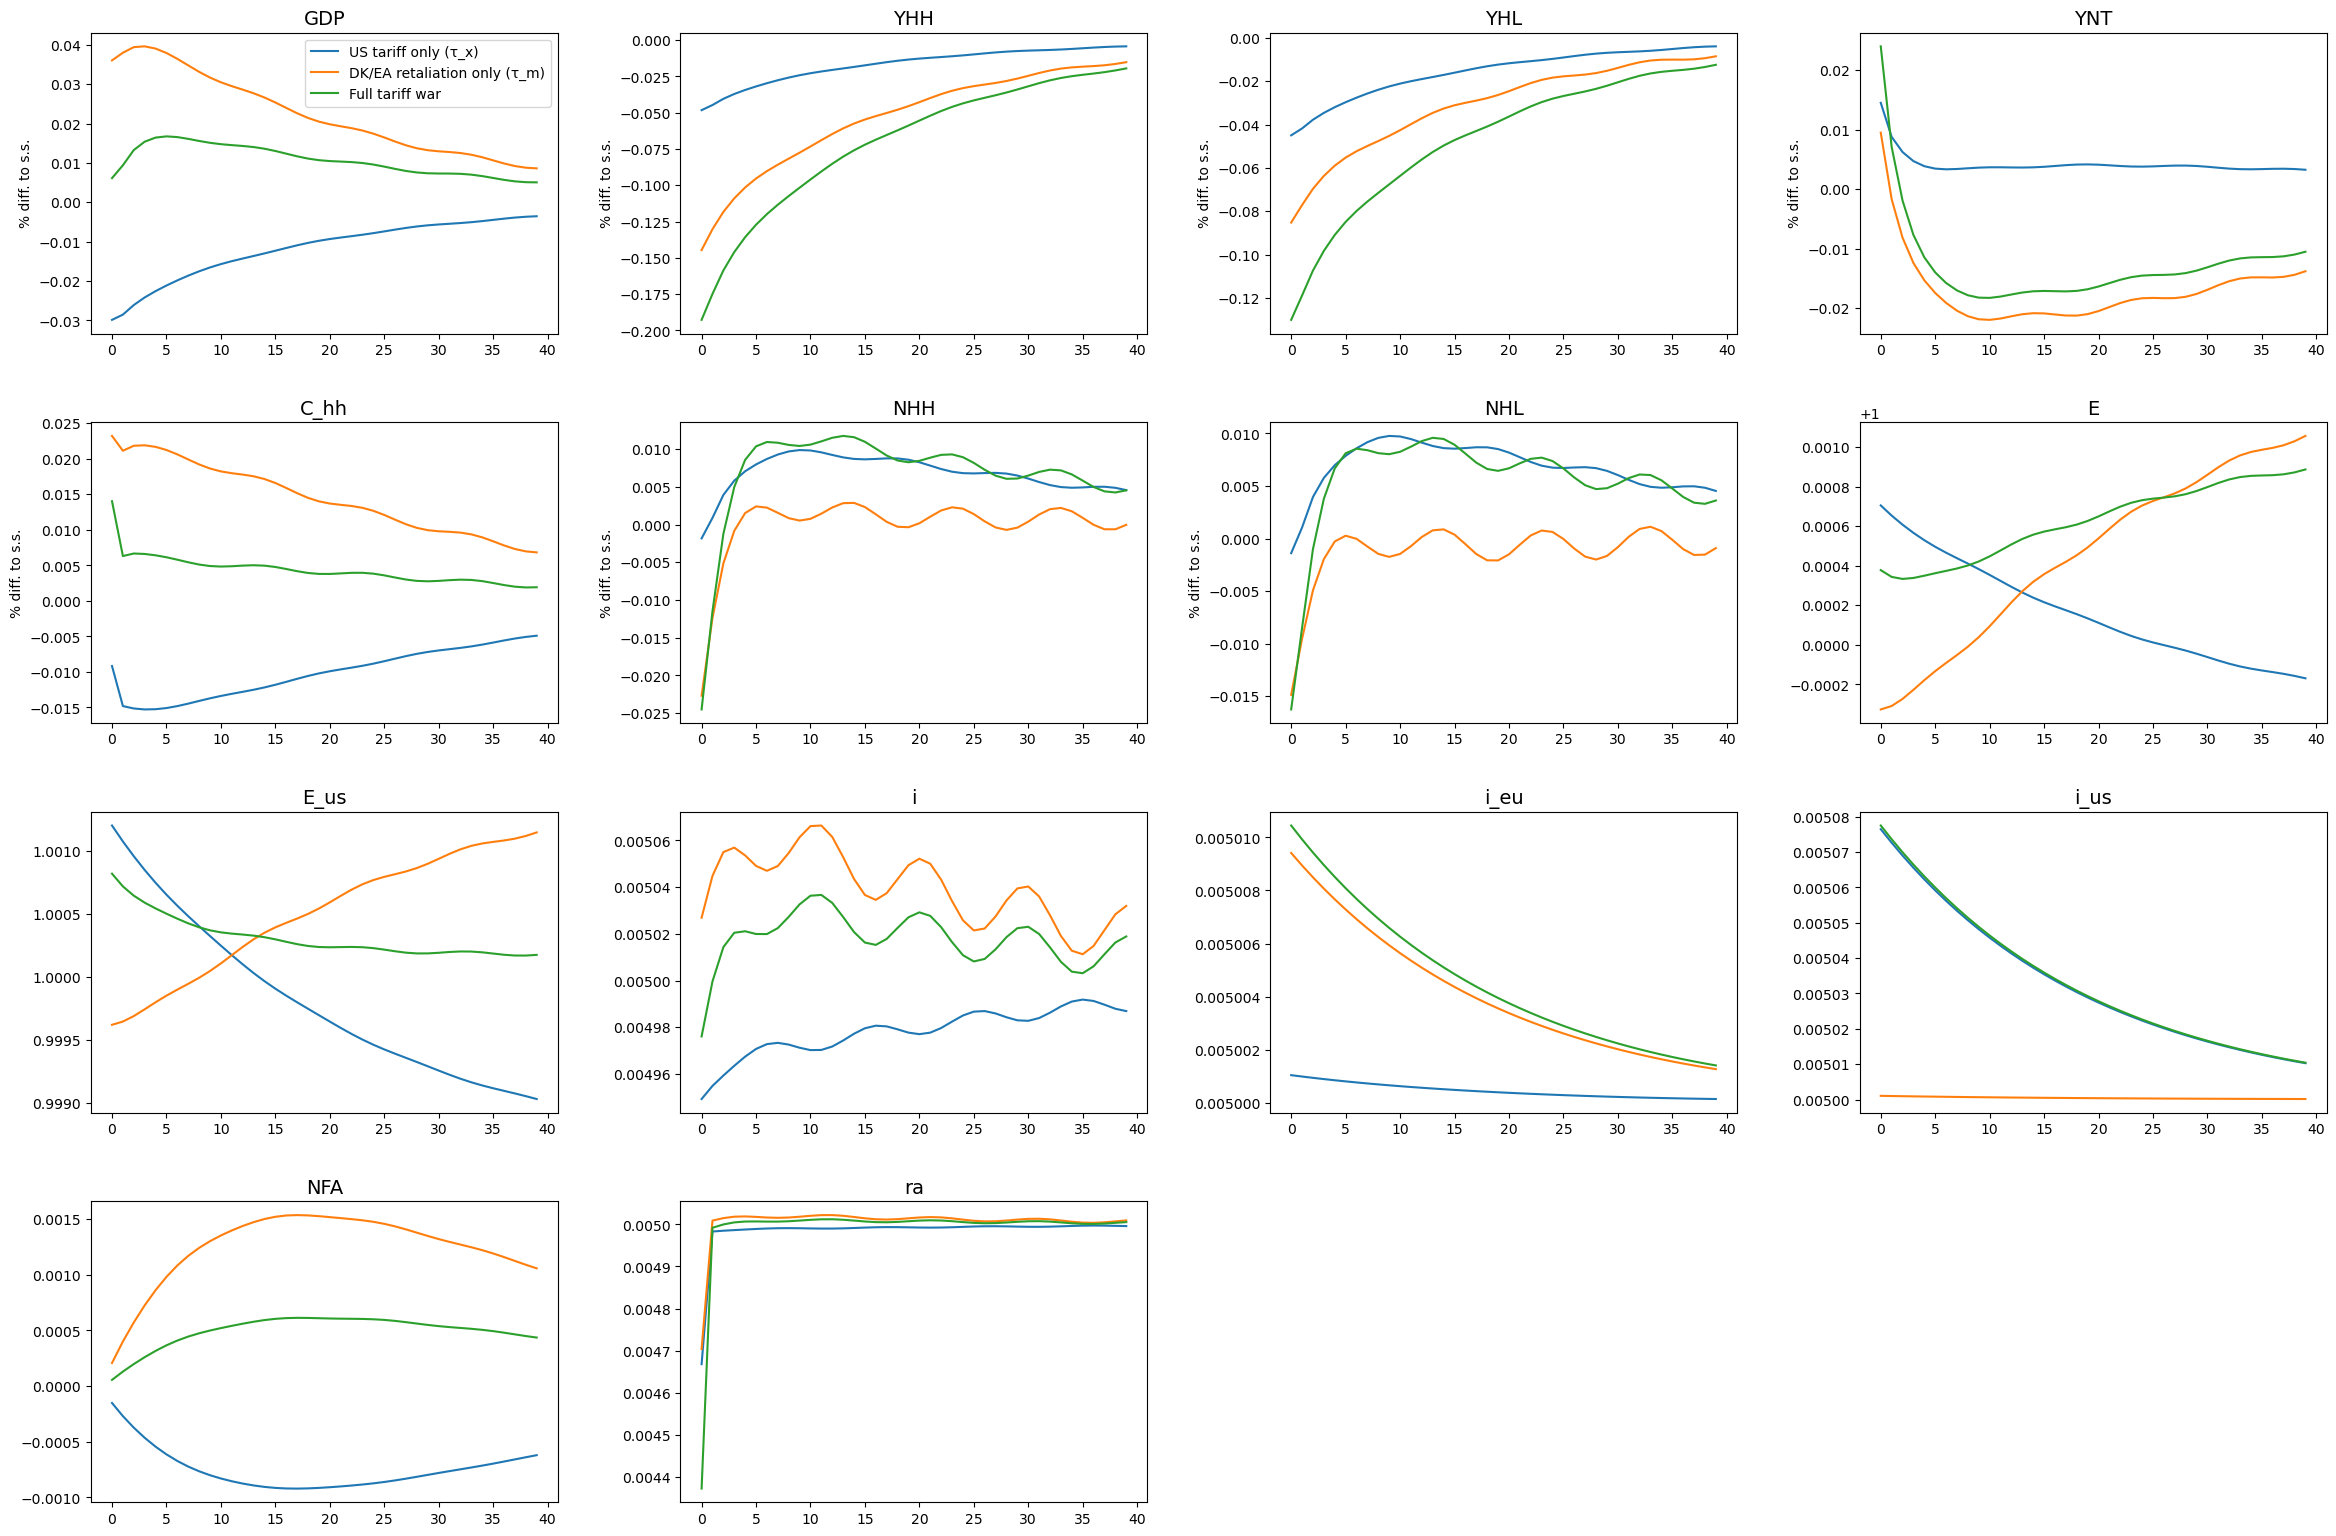

<Figure size 640x480 with 0 Axes>

In [ ]:
# Variables shown in levels (rates and prices — not log-deviations)
lvl_value = ['pi', 'pi_eu', 'pi_us', 'tau', 'r', 'ra', 'i', 'i_eu', 'i_us',
             'tau_m', 'tau_x', 'E', 'E_us', 'NFA']

# Models and labels for comparison
models = [mf_tau_x, mf_tau_m, mf_war]
labels = ['US tariff only (τ_x)', 'DK/EA retaliation only (τ_m)', 'Full tariff war']

model.compare_IRFs(
    models, labels,
    varnames=['GDP', 'YHH', 'YHL', 'YNT', 'C_hh', 'NHH', 'NHL', 'E', 'E_us', 'i', 'i_eu', 'i_us', 'NFA', 'ra'],
    lvl_value=lvl_value,
    T_max=40, ncols=4,
    do_targets=False
)
plt.suptitle('Output and consumption', y=1.02)
plt.tight_layout()
#plt.savefig(os.path.join(folder, 'output_consumption.png'), dpi=150, bbox_inches='tight')

# Domestic shock

## G shock

In [ ]:
m_G = model.copy()

m_G.par.jump_G = 0.01
m_G.par.rho_G  = 0.95

m_G.find_transition_path(shocks=['G'], do_print=False, do_end_check=True)

### shocks ###


c:\users\laedy\gemodeltools-1\GEModelTools\figures.py:107: RuntimeWarning: invalid value encountered in divide
  ax.plot(np.arange(T_max),100*(pathvalue[:T_max]/ssvalue-1),label=label)


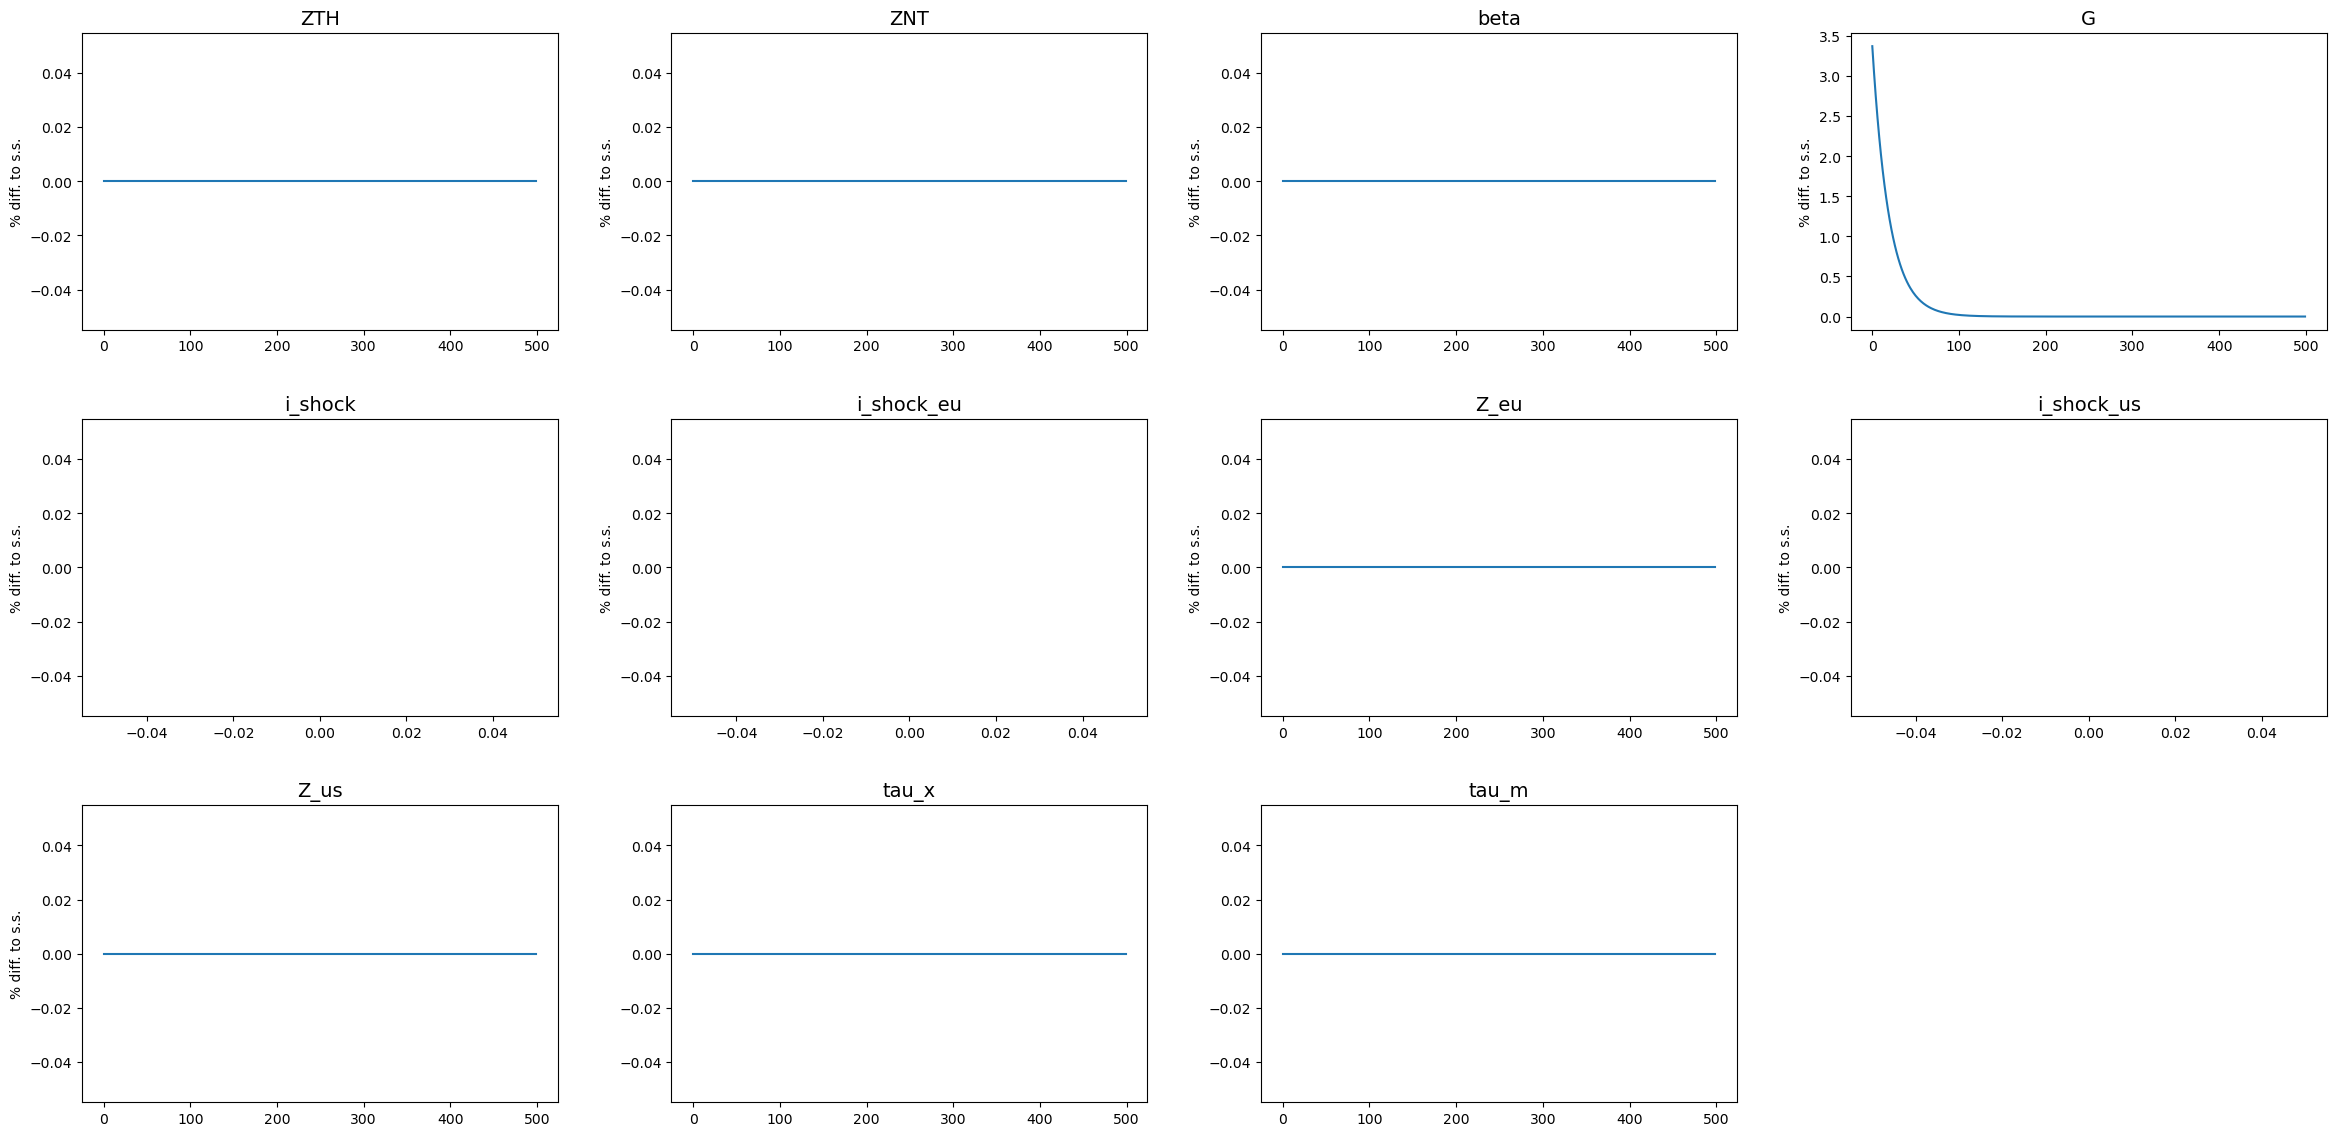


### varnames ###


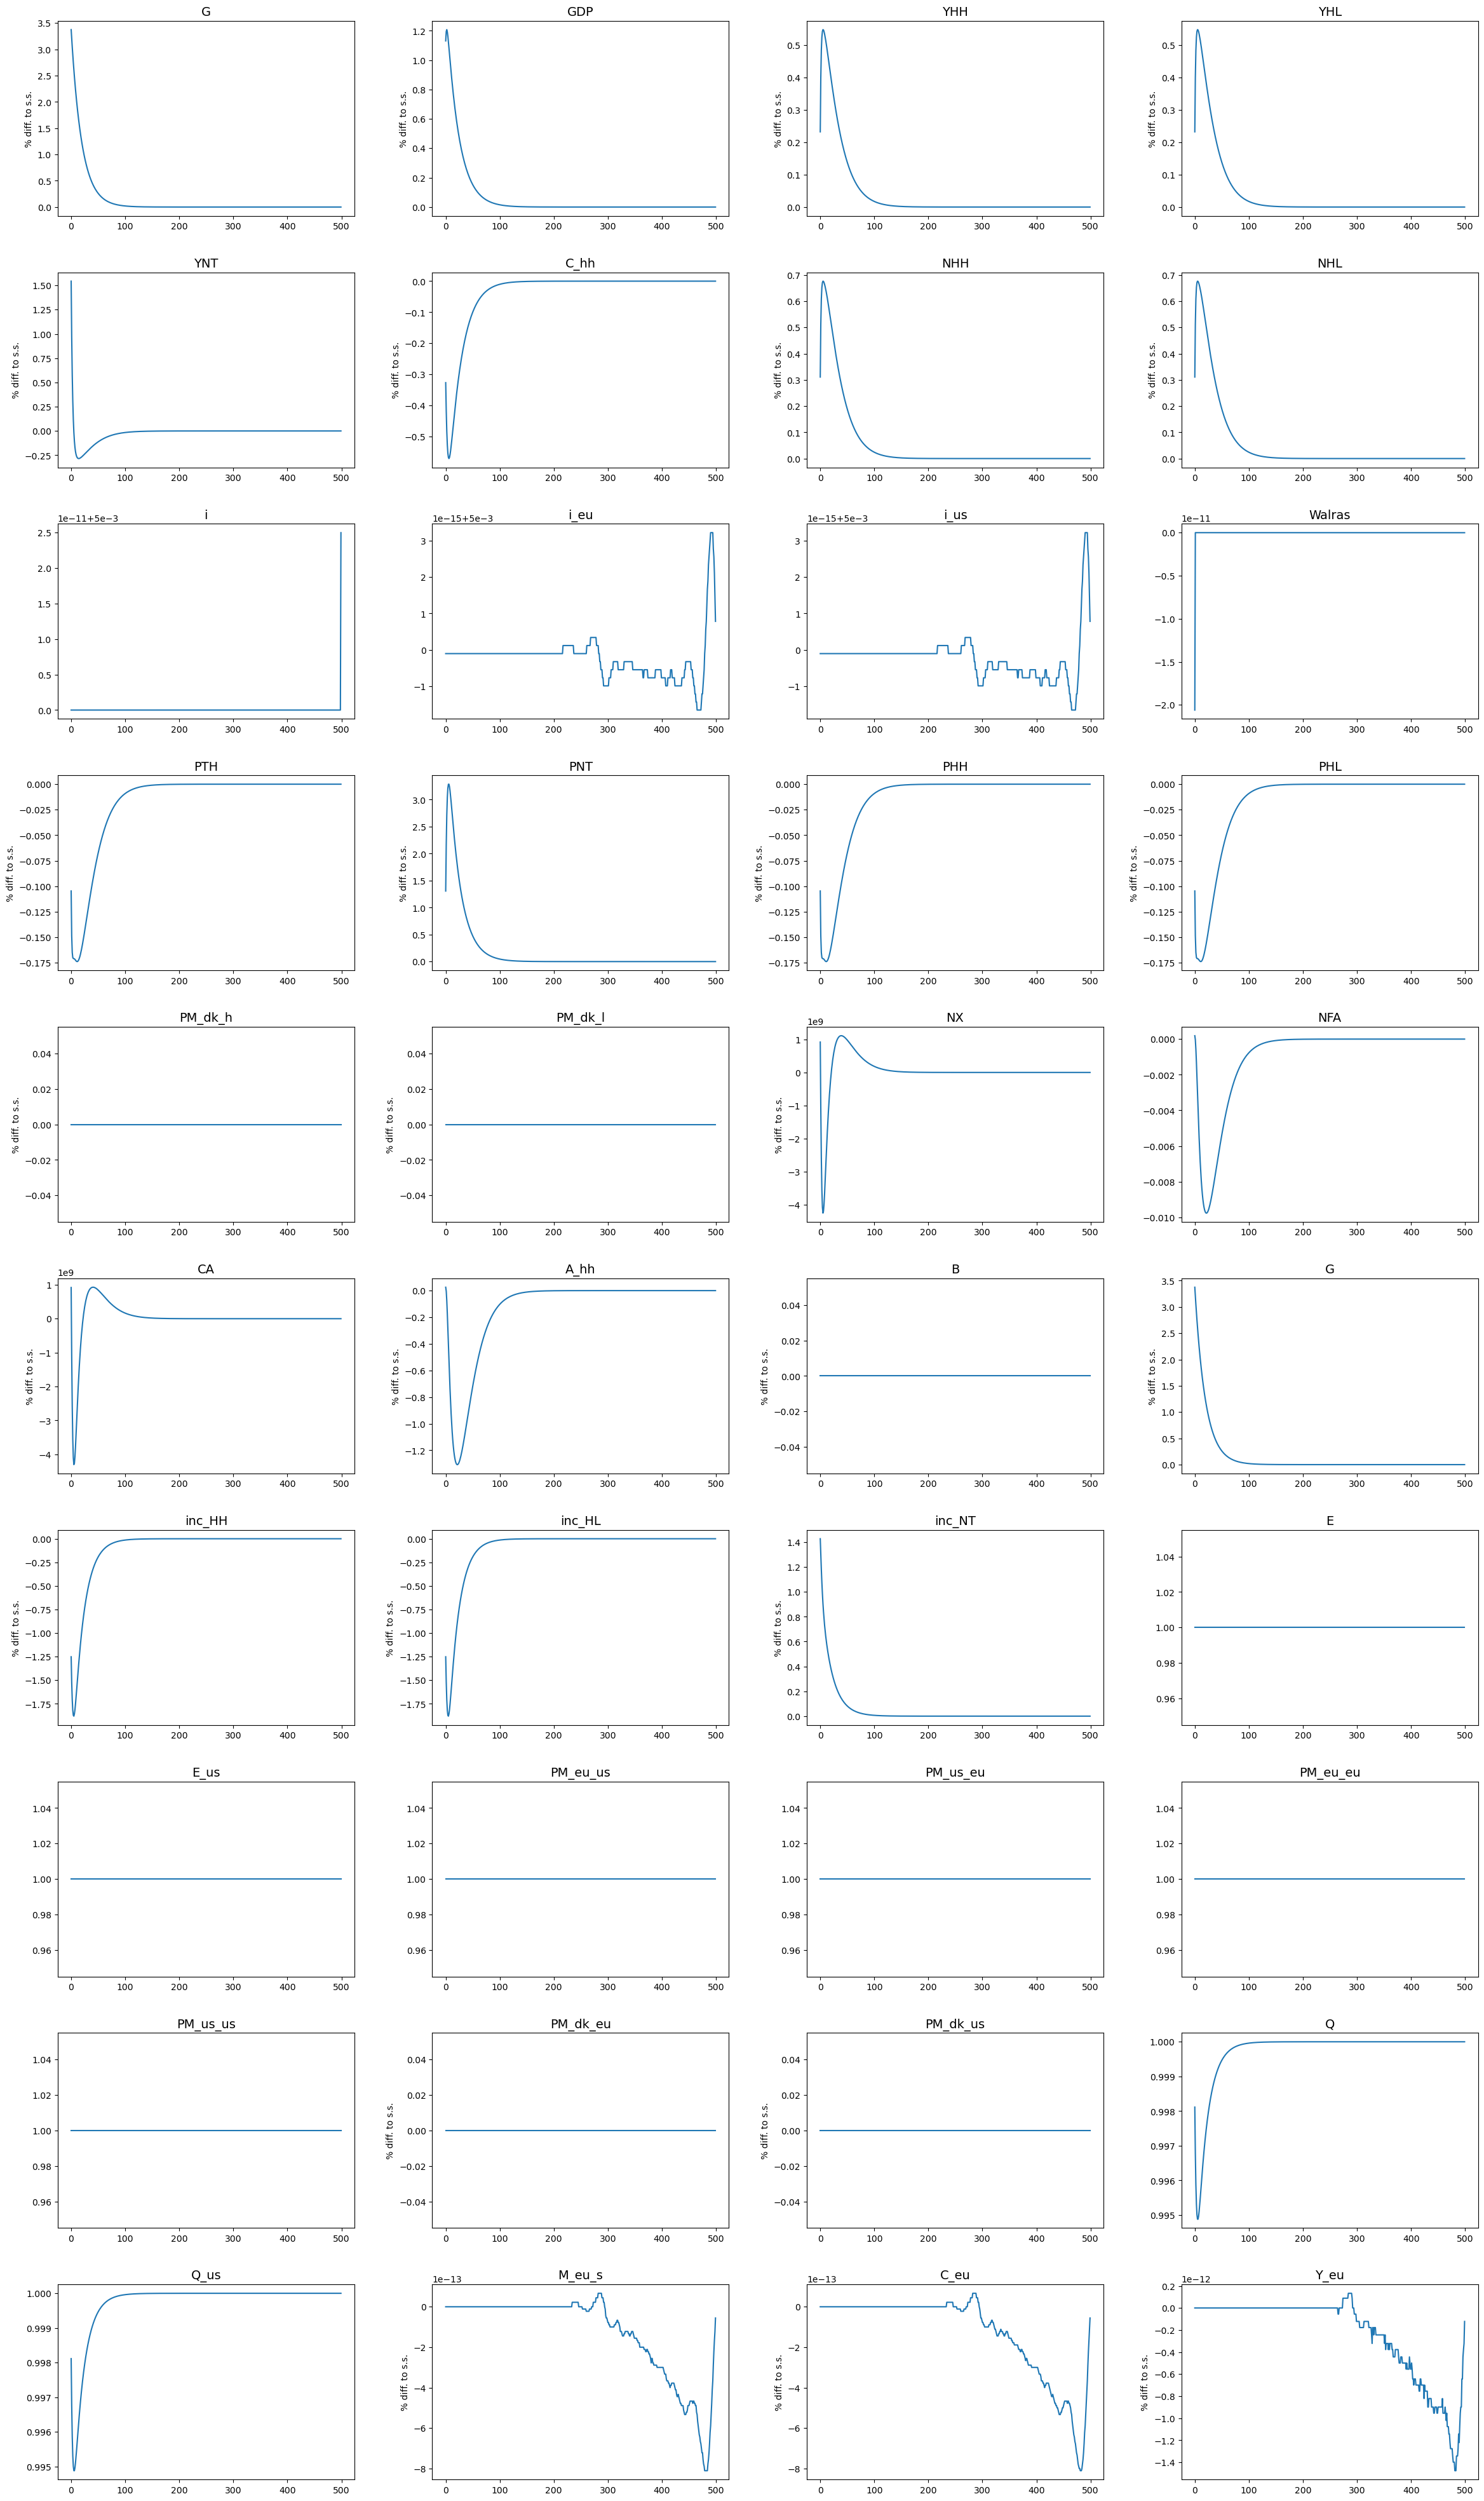


### tagets ###


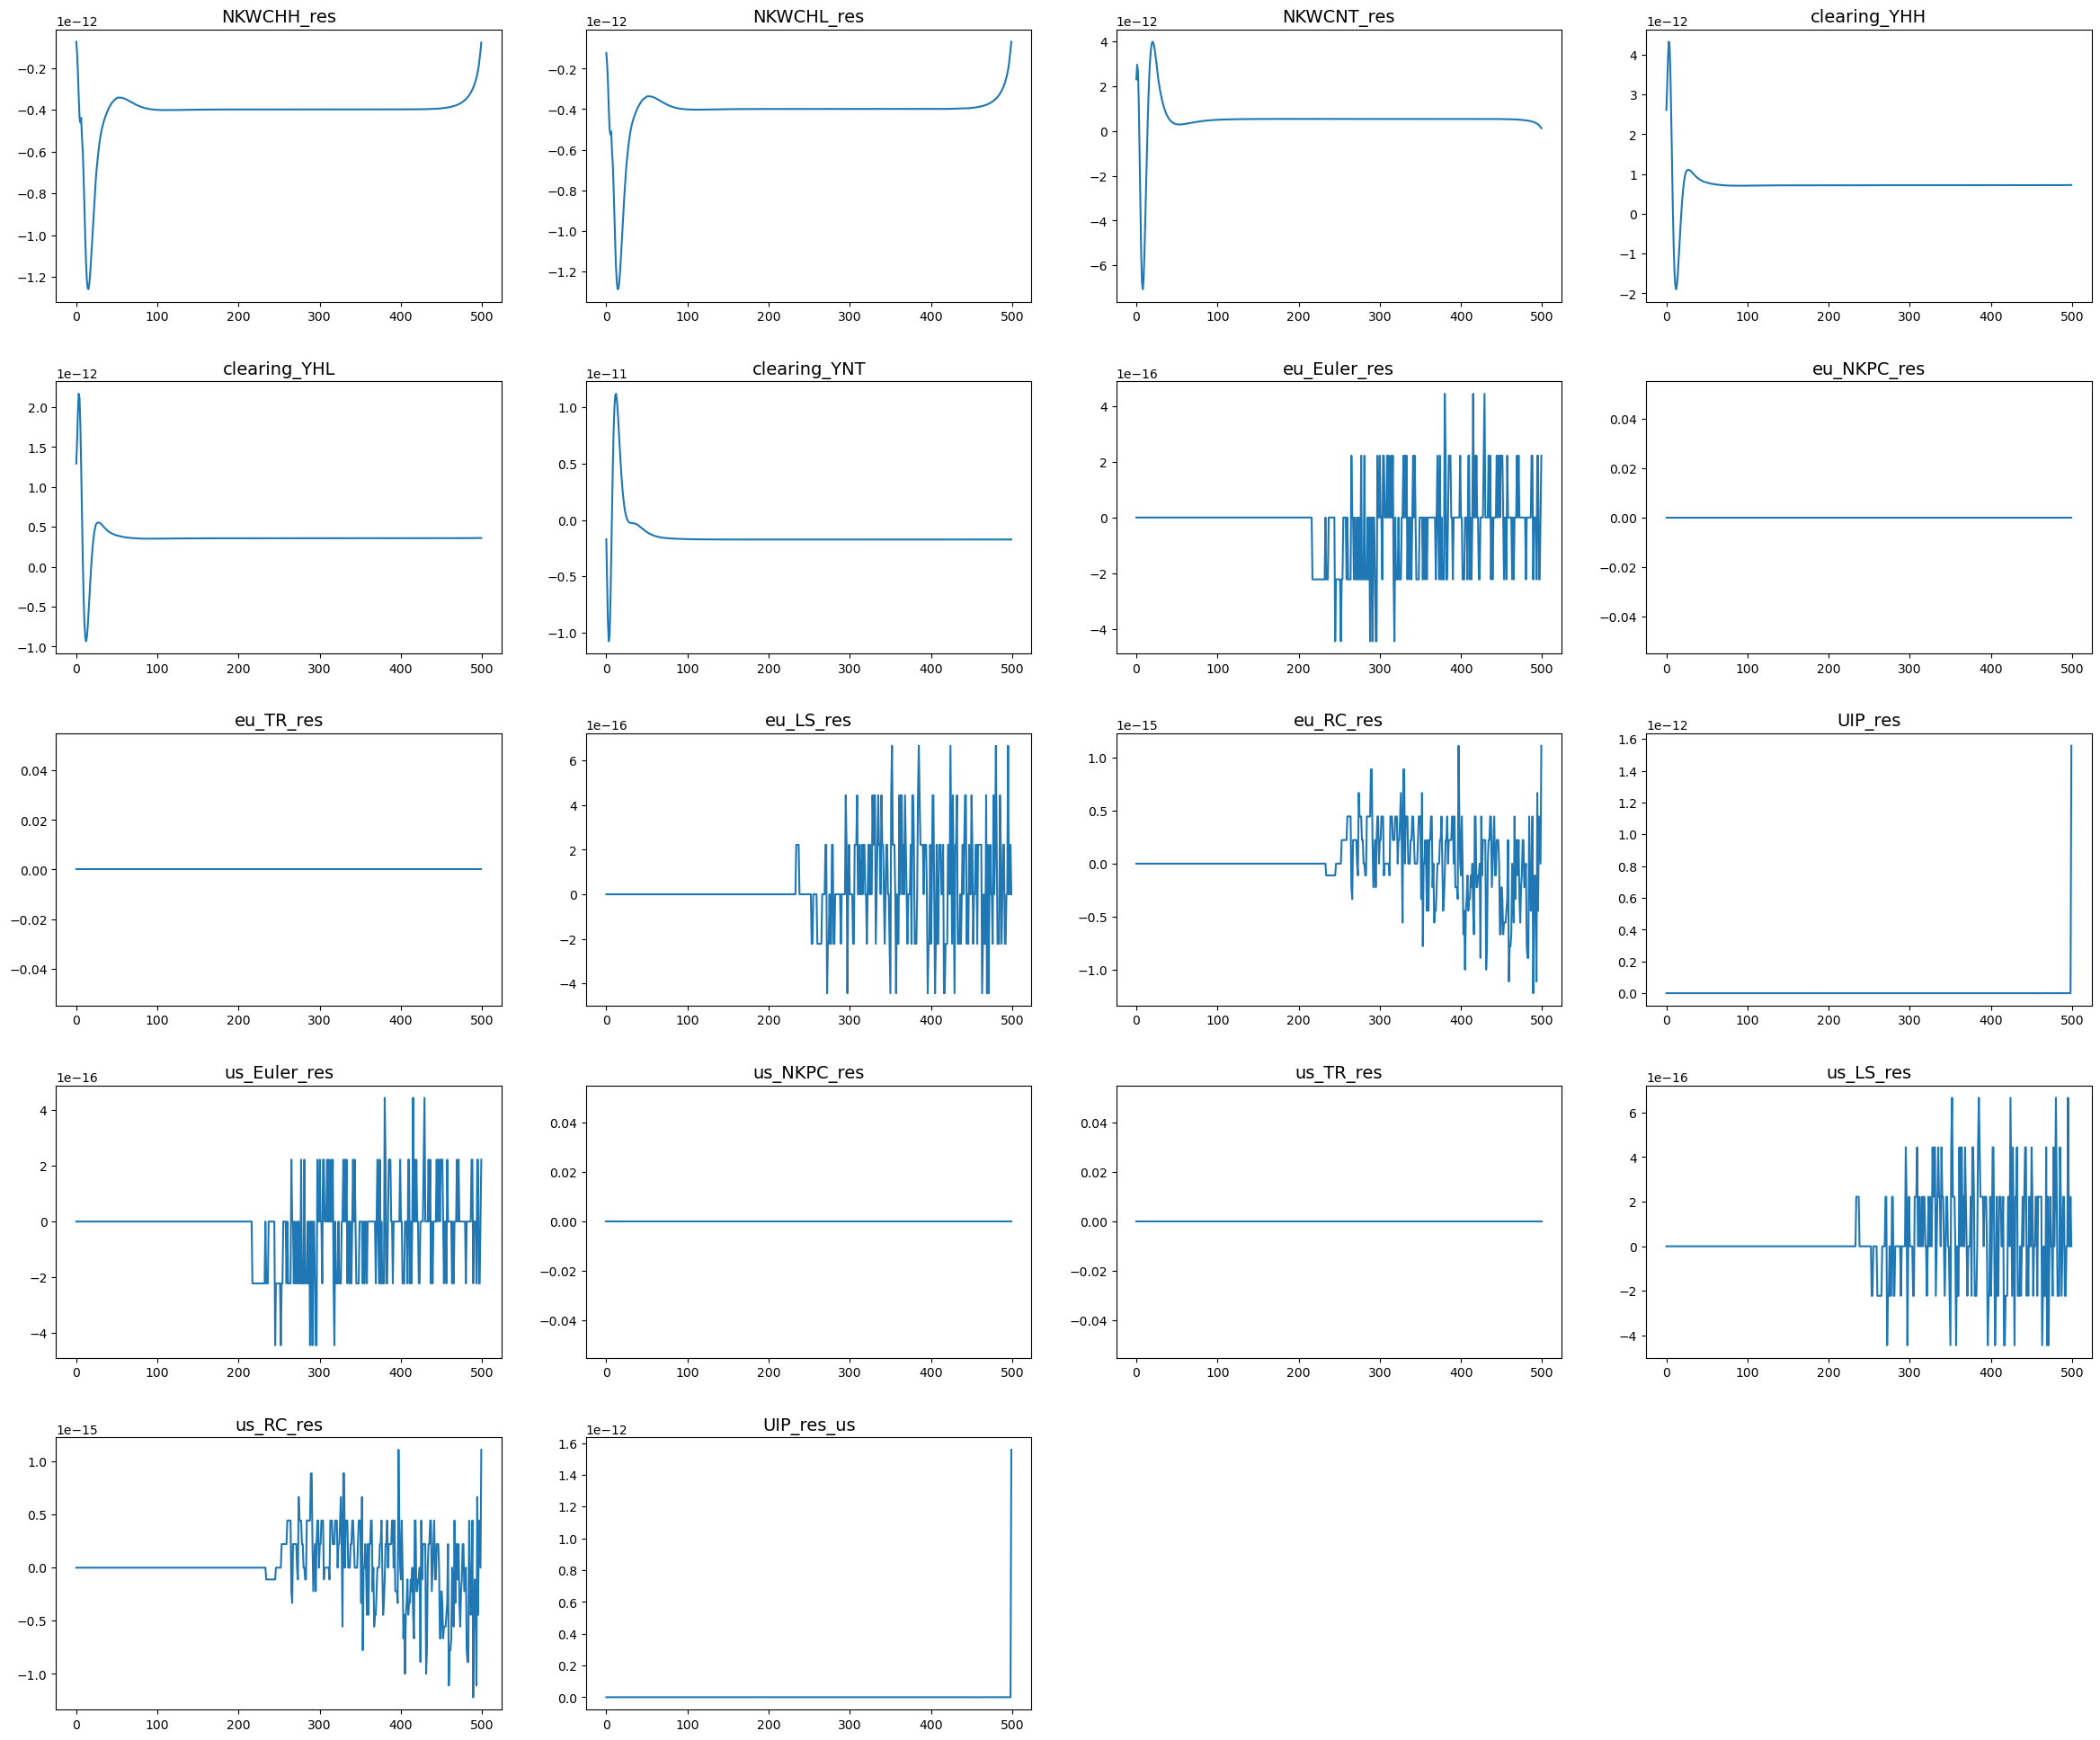

<Figure size 640x480 with 0 Axes>

In [ ]:
# Variables shown in levels (rates and prices — not log-deviations)
lvl_value = ['pi', 'pi_eu', 'pi_us', 'tau', 'r', 'ra', 'i', 'i_eu', 'i_us',
             'tau_m', 'tau_x', 'E', 'E_us', 'NFA', 'Walras', 'PM_eu_us', 'PM_us_eu', 'PM_eu_eu', 'PM_us_us', 'Q', 'Q_us']

# Models and labels for comparison
models = [m_G]
labels = ['Domestic public cons shock (G)'] #, 'DK/EA retaliation only (τ_m)'] , 'Full tariff war']

model.compare_IRFs(
    models, labels,
    varnames=['G', 'GDP', 'YHH', 'YHL', 'YNT', 'C_hh', 'NHH', 'NHL', 'i', 'i_eu', 'i_us', 'Walras',
               'PTH', 'PNT', 'PHH', 'PHL', 'PM_dk_h', 'PM_dk_l', 'NX', 'NFA', 'CA', 'A_hh', 'B', 'G', 'inc_HH', 'inc_HL', 'inc_NT',
                'E', 'E_us', 'PM_eu_us', 'PM_us_eu', 'PM_eu_eu', 'PM_us_us', 'PM_dk_eu', 'PM_dk_us', 'Q', 'Q_us',
                'M_eu_s', 'C_eu', 'Y_eu'],
    lvl_value=lvl_value,
    T_max=500, ncols=4,
    do_targets=True
)
plt.suptitle('Output and consumption', y=1.02)
plt.tight_layout()
#plt.savefig(os.path.join(folder, 'output_consumption.png'), dpi=150, bbox_inches='tight')